# Safe Multimodal Decompensation Forecasting in Intensive Care: Joint Modeling of High-Frequency MIMIC-IV Telemetry and Unstructured Clinical Notes with Selective Deferral

### Abstract & Research Framing (ACM Style)

In intensive care units (ICUs), clinical decision support systems trained on electronic health record (EHR) data can provide early warnings for acute physiological decompensation (e.g., 30-day post-ICU mortality, septic shock, or cardiac collapse). However, conventional clinical machine learning models suffer from two critical vulnerabilities:  

1. **Single-Modality Isolation**: Models typically process either continuous bedside telemetry (chartevents/labevents) or unstructured clinical text (note), missing the complementary interplay between real-time physiological vitals and qualitative clinical observations.  

2. **Forced-Choice Inference**: Standard neural networks produce point predictions for every patient regardless of missing telemetry, severe artifactual noise, or high predictive ambiguity. Uncalibrated false negative predictions cause silent clinical failures and delayed resuscitation, while false positives induce severe alarm fatigue.  

To address these challenges under extreme class imbalance (<10% positive events), this project implements **Multimodal EHR Fusion with Selective Clinical Deferral (MM-SCD)**. Using the MIMIC-IV database, the system fuses 24-hour regularized physiological time-series (processed via a 2-layer Bi-LSTM) with unstructured clinical progress notes (processed via Bio_ClinicalBERT) using a dynamic **Cross-Attention Fusion Layer**.  

Instead of forcing a prediction on ambiguous trajectories, the system measures normalized predictive Shannon Entropy $H(X)$. When $H(X) > \gamma$, the system defers prediction to human clinical rapid response teams.  

This project addresses key technical challenges: dual-modality neural cross-attention alignment, learning under severe EHR class imbalance via Focal Loss, differential learning rate optimization, and information-theoretic selective classification.

### Technical & Architectural

To elevate this codebase for your course report and presentation submission, the code includes the following enhancements:  

* **Modality Ablation Suite**: Implements both unimodal baselines (**Time-Series Only Bi-LSTM and ClinicalBERT Text Only**) alongside the **Multimodal Cross-Attention Model** to evaluate multimodal performance gains.
* **Optimization & Training Stability**: Incorporates differential learning rates ($2 \times 10^{-5}$ for ClinicalBERT, $1 \times 10^{-3}$ for attention/LSTM heads), gradient clipping, and validation tracking to prevent optimization bottlenecks.  
* **Comprehensive Clinical Evaluation**: Computes standard discriminative metrics (**AUROC, AUPRC**), calibration performance (**Expected Calibration Error - ECE**), and selective classification metrics across varying coverage thresholds $\Phi(\gamma)$.  
* **Cost-Aware System Loss Analysis ($L_{sys}$)**: Evaluates trade-offs between automated classification error $c_{err}$ and clinical review cost $c_{defer}$.
* **Diagnostic Visualization Suite**: Automatically generates publication-ready figures for your ACM report and presentation slides:  

  1. Risk-Coverage Curve across modalities (Multimodal vs. Unimodal Baselines).  

  2. Predictive Entropy Distribution comparing correct predictions vs. error cases.  
  3. ROC & Precision-Recall Curves under full population coverage.  
  4. Cost-Aware System Loss $L_{sys}(\Phi)$ Curve identifying optimal clinical operating points.  
  5. Cross-Attention Alignment Heatmap showing dynamic text token weighting conditioned on temporal physiological state.

### Environment Setup & Package Installation

Before running the core pipeline, we need to ensure all external dependencies are available in the current environment. The code block below installs `torchmetrics`, a specialized library that provides heavily optimized, hardware-accelerated PyTorch implementations for evaluating classification metrics (like AUROC and AUPRC). Using `torchmetrics` ensures our evaluation is both fast and numerically stable during the training loop.

In [1]:
!pip install -q torchmetrics

### Import Required Dependencies

This section imports all the necessary Python libraries that power our multimodal architecture. We load `torch` and `torch.nn` for building the deep learning models, `transformers` from Hugging Face for tokenizing and processing the clinical text via Bio_ClinicalBERT, and standard data science tools like `pandas` and `numpy` for data manipulation. We also import `matplotlib`, `seaborn`, and `plotly` to handle our advanced diagnostic visualizations later on.

In [2]:
# ==============================================================================
# IMPORT DEPENDENCIES
# ==============================================================================

import copy
import os
import math
import random
import time

from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchmetrics.functional.classification as TMF

from transformers import AutoTokenizer, AutoModel, logging as hf_logging


import google.auth
from google.colab import auth
from google.cloud import bigquery
from google.api_core.exceptions import GoogleAPICallError, Forbidden

### Reproducibility & Compute Device Initialization

Machine learning models rely heavily on random weight initialization and stochastic optimization. To ensure that our experiments are 100% reproducible and yield the exact same results across different runs, the code below locks the random seeds for Python, NumPy, and PyTorch. Additionally, it detects whether a GPU (`cuda`) is available to accelerate training, falling back to the `cpu` if necessary.

In [3]:
# ==============================================================================
# IMPORT DEPENDENCIES, REPRODUCIBILITY & DEVICE INITIALIZATION
# ==============================================================================

# Establish strict reproducibility across all random state generators
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Select hardware compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Execution environment initialized on compute device: {device}")

# Suppress non-critical Hugging Face warnings
hf_logging.set_verbosity_error()
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

Execution environment initialized on compute device: cuda


### Google Cloud & BigQuery Authentication

The MIMIC-IV dataset is securely hosted on Google BigQuery. To access it, we must securely authenticate our environment. The block below attempts to log in using Google Colab's native authentication or Kaggle's Application Default Credentials. Once authenticated, it initializes a `bigquery.Client` that acts as our bridge to query the massive electronic health record (EHR) database directly from this notebook.

In [4]:
# ==============================================================================
# GOOGLE CLOUD AUTHENTICATION & BIGQUERY CLIENT SETUP (COLAB + KAGGLE)
# ==============================================================================

project_id = 'mimic-sql-500713'  # Your GCP Project ID
client = None
HAS_BIGQUERY = True

print("Initializing BigQuery authentication...")

# Securely authenticate Google account to allow access to BigQuery EHR data
try:
    from google.colab import auth
    auth.authenticate_user()
    credentials, _ = google.auth.default()
    client = bigquery.Client(project=project_id, credentials=credentials)
    print("Successfully authenticated via Google Colab!")
    HAS_BIGQUERY = True

# 2. Fall back to Kaggle / Application Default Credentials Flow
except ImportError:
    print("Google Colab library not found. Attempting Kaggle / ADC authentication...")
    try:
        credentials, default_project = google.auth.default()
        # Use specified project_id if provided, otherwise default to credentials project
        target_project = project_id if project_id else default_project
        client = bigquery.Client(project=target_project, credentials=credentials)
        print(f"Successfully authenticated via Kaggle / ADC (Project: {target_project})!")
        HAS_BIGQUERY = True
    except Exception as e:
        print(f"Kaggle/ADC Authentication Failed: {e}")
        print("\n[!] Kaggle Setup Tip: Ensure you have attached your Google Account in Kaggle:")
        print("    Go to 'Add-ons' menu -> 'Google Cloud SDK' (or 'Google Account') -> Link Account.")
        HAS_BIGQUERY = False

except Exception as e:
    print(f"Colab Authentication failed: {e}")
    HAS_BIGQUERY = False

if not HAS_BIGQUERY:
    print("Running in local simulation mode.")

Successfully authenticated via Google Colab!


### Database Connection & Permission Verification

Before running complex data extraction queries, it is best practice to verify our access permissions. The following code pings the `physionet-data` project on BigQuery and lists the available datasets. If it successfully retrieves dataset names like `mimiciv_3_1_icu`, we know our account has the proper data use agreements (DUA) approved by PhysioNet to proceed.

In [5]:
# ==============================================================================
# DATABASE CONNECTION & SCHEMA VERIFICATION
# ==============================================================================

if HAS_BIGQUERY and client is not None:
    try:
        print("\n--- Testing BigQuery Access to 'physionet-data' ---")
        datasets = list(client.list_datasets(project="physionet-data"))
        print(f"Successfully connected! Found {len(datasets)} datasets in physionet-data:")
        for dataset in datasets[:5]:  # Print first 5 datasets
            print(f"  - {dataset.dataset_id}")
    except (GoogleAPICallError, Forbidden) as e:
        print(f"GCP Permission Error: Ensure your GCP project '{project_id}' and linked Google Account")
        print(f"have been granted access to PhysioNet datasets. Details:\n{e}")
    except Exception as e:
        print(f"Unexpected connection error: {e}")
else:
    print("Skipping BigQuery dataset check (Local execution).")


--- Testing BigQuery Access to 'physionet-data' ---
Successfully connected! Found 8 datasets in physionet-data:
  - mimiciii_clinical
  - mimiciii_derived
  - mimiciii_notes
  - mimiciii_notes_derived
  - mimiciv_3_1_derived


### MIMIC-IV Cohort Definition & SQL Extraction Queries

Here we define the actual SQL queries used to extract our raw patient data.
1. **Metadata Query:** Pulls demographic info (age, gender), 30-day mortality labels, and aggregates the first 24 hours of unstructured clinical progress notes for each ICU stay.
2. **Time-Series Query:** Extracts high-frequency bedside telemetry (like Heart Rate and SpO2 from `chartevents`) and laboratory results (like Lactate from `labevents`) over the same initial 24-hour window.

In [6]:
# ==============================================================================
# BIGQUERY SQL EXTRACTION QUERIES (MIMIC-IV)
# ==============================================================================

# SQL Query 1: Extract cohort demographic metadata, 30-day mortality labels, and initial 24h progress notes
MIMIC_METADATA_BIGQUERY_SQL = """
WITH cohort AS (
  SELECT
    ie.subject_id, ie.hadm_id, ie.stay_id, ie.intime, ie.outtime,
    p.gender, p.anchor_age, p.dod
  FROM `physionet-data.mimiciv_3_1_icu.icustays` ie
  JOIN `physionet-data.mimiciv_3_1_hosp.patients` p ON ie.subject_id = p.subject_id
  WHERE TIMESTAMP_DIFF(ie.outtime, ie.intime, HOUR) >= 24
    AND p.anchor_age >= 18
),
notes AS (
  SELECT
    c.stay_id, STRING_AGG(n.text, ' ') AS combined_notes
  FROM cohort c
  JOIN `physionet-data.mimiciv_note.discharge` n ON c.hadm_id = n.hadm_id
  WHERE n.charttime BETWEEN c.intime AND TIMESTAMP_ADD(c.intime, INTERVAL 24 HOUR)
  GROUP BY c.stay_id
)
SELECT
  c.stay_id, c.anchor_age, c.gender,
  CASE WHEN c.dod IS NOT NULL AND c.dod <= TIMESTAMP_ADD(c.intime, INTERVAL 30 DAY) THEN 1 ELSE 0 END AS decompensation_label,
  COALESCE(n.combined_notes, 'No progress notes recorded during initial 24 hours.') AS note_text
FROM cohort c
LEFT JOIN notes n ON c.stay_id = n.stay_id;
"""

# SQL Query 2: Extract 24-hour vital signs (Chartevents) and laboratory events (Labevents)
MIMIC_TS_BIGQUERY_SQL = """
WITH cohort AS (
  SELECT stay_id, intime
  FROM `physionet-data.mimiciv_3_1_icu.icustays`
  WHERE TIMESTAMP_DIFF(outtime, intime, HOUR) >= 24
),
vitals AS (
  SELECT
    c.stay_id, ce.itemid, ce.valuenum,
    TIMESTAMP_DIFF(ce.charttime, c.intime, HOUR) AS hour_step
  FROM cohort c
  JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce ON c.stay_id = ce.stay_id
  WHERE ce.charttime BETWEEN c.intime AND TIMESTAMP_ADD(c.intime, INTERVAL 24 HOUR)
    AND ce.itemid IN (220045, 220052, 220210, 220277, 223761)
),
labs AS (
  SELECT
    c.stay_id, le.itemid, le.valuenum,
    TIMESTAMP_DIFF(le.charttime, c.intime, HOUR) AS hour_step
  FROM cohort c
  JOIN `physionet-data.mimiciv_3_1_icu.icustays` ie ON c.stay_id = ie.stay_id
  JOIN `physionet-data.mimiciv_3_1_hosp.labevents` le ON ie.hadm_id = le.hadm_id
  WHERE le.charttime BETWEEN c.intime AND TIMESTAMP_ADD(c.intime, INTERVAL 24 HOUR)
    AND le.itemid IN (50813, 50912, 51301)
)
SELECT * FROM vitals UNION ALL SELECT * FROM labs;
"""

print("SQL Query definitions compiled successfully.")

SQL Query definitions compiled successfully.


### Data Extraction & Robust Synthetic Fallback Engine

This cell executes the SQL queries defined above to pull real MIMIC-IV data into pandas DataFrames. However, because MIMIC-IV requires formal credentialing, we have built a **Synthetic Fallback Engine**. If the BigQuery connection fails (e.g., if a new reader lacks access), the code automatically generates a realistic, statistically accurate synthetic dataset of 800 patients. This ensures the entire notebook remains runnable and educational for anyone.

In [7]:
# ==============================================================================
# BIGQUERY EXTRACTION & SYNTHETIC FALLBACK ENGINE
# ==============================================================================

if HAS_BIGQUERY:
    try:
        print("Fetching metadata and telemetry from BigQuery...")
        df_metadata = client.query(MIMIC_METADATA_BIGQUERY_SQL).to_dataframe()
        df_ts = client.query(MIMIC_TS_BIGQUERY_SQL).to_dataframe()
        dict_timeseries = {stay_id: group for stay_id, group in df_ts.groupby('stay_id')}
        print(f"Successfully extracted {len(df_metadata)} ICU stays from BigQuery!")

    except (Forbidden, GoogleAPICallError, Exception) as e:
        print(f"\n[BigQuery Access Warning]: {e}")
        print("Switching to physiological synthetic dataset fallback...\n")
        HAS_BIGQUERY = False

if not HAS_BIGQUERY:
    num_stays = 800
    stay_ids = [10000 + i for i in range(num_stays)]
    metadata_list = []
    dict_timeseries = {}

    # Standard MIMIC-IV Item IDs: HR, MAP, RR, SpO2, Temp, Lactate, WBC, Creatinine
    feature_itemids = [220045, 220052, 220210, 220277, 223761, 50813, 50912, 51301]

    # Baseline physiological normal ranges (Mean, Std, Min, Max)
    vitals_baseline = {
        220045: (75.0, 10.0, 30.0, 220.0),    # Heart Rate (bpm)
        220052: (85.0, 8.0, 30.0, 150.0),     # Mean Arterial Pressure (mmHg)
        220210: (16.0, 3.0, 6.0, 45.0),       # Respiratory Rate (bpm)
        220277: (97.0, 1.5, 50.0, 100.0),     # SpO2 (%)
        223761: (37.0, 0.4, 32.0, 42.0),      # Temperature (°C)
        50813:  (1.2, 0.3, 0.5, 20.0),       # Lactate (mmol/L)
        50912:  (8.5, 2.0, 1.0, 50.0),       # WBC (k/uL)
        51301:  (0.9, 0.2, 0.2, 12.0)        # Creatinine (mg/dL)
    }

    decomp_notes = [
        "Patient in acute respiratory distress and severe hypotension. Lactate rising rapidly; fluid resuscitation initiated.",
        "Clinical status deteriorating. Persistent tachycardia and low MAP despite vasopressor titration. ICU team at bedside.",
        "Rapid decompensation noted over last 4 hours. Decreased urine output, altered mental status, and severe hypoxemia."
    ]

    stable_notes = [
        "Patient hemodynamically stable. Sinus rhythm maintained. Vital signs within acceptable baseline parameters.",
        "Routine ICU monitoring. Tolerating oral intake and weaning off supplemental oxygen. No acute distress.",
        "Stable post-operative course. Lab parameters trending toward normal. Continue current management plan."
    ]

    for sid in stay_ids:
        label = np.random.choice([0, 1], p=[0.88, 0.12])  # Realistic ~12% decompensation rate
        age = np.random.randint(18, 89)
        gender = np.random.choice(['M', 'F'])
        note = np.random.choice(decomp_notes) if label == 1 else np.random.choice(stable_notes)

        metadata_list.append({
            'stay_id': sid,
            'anchor_age': age,
            'gender': gender,
            'decompensation_label': label,
            'note_text': note
        })

        rows = []
        for h in range(24):
            # Decompensation trajectory factor (progressive worsening in final 12 hours)
            deterioration = (h / 24.0) ** 2 if (label == 1 and h >= 12) else 0.0

            for fid in feature_itemids:
                if np.random.rand() > 0.15:  # ~15% realistic clinical missingness
                    mean_val, std_val, min_val, max_val = vitals_baseline[fid]

                    # Apply clinical trends for deteriorating patients
                    if fid == 220045:    mean_val += deterioration * 45.0   # Tachycardia
                    elif fid == 220052:  mean_val -= deterioration * 30.0   # Hypotension
                    elif fid == 220210:  mean_val += deterioration * 12.0   # Tachypnea
                    elif fid == 220277:  mean_val -= deterioration * 10.0   # Hypoxemia
                    elif fid == 50813:   mean_val += deterioration * 4.5    # Lactic acidosis

                    val = np.clip(np.random.normal(loc=mean_val, scale=std_val), min_val, max_val)
                    rows.append({'stay_id': sid, 'itemid': fid, 'valuenum': val, 'hour_step': h})

        dict_timeseries[sid] = pd.DataFrame(rows)

    df_metadata = pd.DataFrame(metadata_list)
    print(f"Realistic physiological dataset generated successfully: {len(df_metadata)} stays.")

Fetching metadata and telemetry from BigQuery...


/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Successfully extracted 75672 ICU stays from BigQuery!


### Multimodal Data Containers & Batch Generators

Managing text tokens, time-series grids, and missingness masks simultaneously can get messy. The code below defines a neat `@dataclass` called `MaskAwareMultimodalInput` that holds all these PyTorch tensors together. It acts as a standardized envelope for our data. We also define a synthetic batch generator here to quickly stress-test our neural network architectures and ensure they fit into GPU memory before starting the real training loop.

In [8]:
# ==============================================================================
# MULTIMODAL DATA CONTAINERS & BATCH GENERATOR.
# ==============================================================================


@dataclass
class MaskAwareMultimodalInput:
    """
    Structured data container for multimodal clinical tensors.
    Explicitly tracks time-series vitals, binary missingness masks,
    and text token representations.
    """
    vitals: torch.Tensor          # Shape: [Batch, Seq_Len (24), Num_Vitals (8)].
    observed_mask: torch.Tensor   # Shape: [Batch, Seq_Len (24), Num_Vitals (8)].
    input_ids: torch.Tensor       # Shape: [Batch, Max_Token_Len (256)].
    attention_mask: torch.Tensor  # Shape: [Batch, Max_Token_Len (256)].
    labels: Optional[torch.Tensor] = None

    def get_combined_timeseries(self) -> torch.Tensor:
        """Concatenates normalized vitals with binary missingness indicators -> [Batch, 24, 16]."""
        # Merge the actual values with their observation mask to inform the model of missingness.
        return torch.cat([self.vitals, self.observed_mask], dim=-1)

    def to(self, device: torch.device) -> 'MaskAwareMultimodalInput':
        """Transfers all underlying tensors to compute device."""
        # Safely move all tensors to the target hardware device (CPU or GPU).
        return MaskAwareMultimodalInput(
            vitals=self.vitals.to(device),
            observed_mask=self.observed_mask.to(device),
            input_ids=self.input_ids.to(device),
            attention_mask=self.attention_mask.to(device),
            labels=self.labels.to(device) if self.labels is not None else None
        )


def generate_synthetic_multimodal_batch(
    batch_size: int = 16,
    seq_len: int = 24,
    num_vitals: int = 8,
    max_token_len: int = 256,
    vocab_size: int = 28996,
    device: torch.device = torch.device('cpu')
) -> MaskAwareMultimodalInput:
    """Generates synthetic multimodal batches for rapid architecture dry-runs and VRAM tests."""
    # Create random standard normal tensors for continuous vital signs.
    vitals = torch.randn(batch_size, seq_len, num_vitals, device=device)
    # Create a random boolean mask indicating ~85% observed data.
    observed_mask = (torch.rand(batch_size, seq_len, num_vitals, device=device) > 0.15).float()
    # Generate random integer IDs to simulate tokenized clinical text.
    input_ids = torch.randint(low=100, high=vocab_size, size=(batch_size, max_token_len), device=device)

    # Simulate variable-length text sequences by creating dynamic attention masks.
    text_lengths = torch.randint(low=20, high=max_token_len, size=(batch_size,))
    attention_mask = torch.zeros(batch_size, max_token_len, device=device)
    for i, length in enumerate(text_lengths):
        attention_mask[i, :length] = 1.0

    # Generate random binary classification targets.
    labels = torch.randint(low=0, high=2, size=(batch_size,), device=device)

    # Return the populated container.
    return MaskAwareMultimodalInput(
        vitals=vitals,
        observed_mask=observed_mask,
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print("Block compiled: Container dataclass and Batch Generator ready.")

Block compiled: Container dataclass and Batch Generator ready.


### Multimodal PyTorch Dataset Class

This is the core data preprocessing engine. The `MultimodalICUDatabase` class inherits from PyTorch's `Dataset`. It performs heavy lifting: it converts raw pandas telemetry into structured 24x8 NumPy grids, handles missing clinical data via forward-filling and zero-imputation, normalizes the vitals using Z-scores, and tokenizes the unstructured text notes using the Hugging Face Bio_ClinicalBERT tokenizer. It outputs dictionary payloads ready for the neural network.

In [9]:
# ==============================================================================
# MULTIMODAL DATASET CLASS DEFINITION.
# ==============================================================================


class MultimodalICUDatabase(Dataset):
    def __init__(self, df_metadata, dict_timeseries, tokenizer, max_token_len=256, max_samples=None, global_stats=None):
        # Downsample the metadata if a strict maximum sample limit is provided.
        if max_samples and len(df_metadata) > max_samples:
            df_metadata = df_metadata.sample(n=max_samples, random_state=42).reset_index(drop=True)

        # Store local references to metadata and the huggingface tokenizer.
        self.metadata = df_metadata.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_token_len = max_token_len

        # Define core physiological item IDs to extract from the raw timeseries.
        self.feature_itemids = [220045, 220052, 220210, 220277, 223761, 50813, 50912, 51301]
        self.num_vitals = len(self.feature_itemids)
        self.seq_len = 24

        # Filter out timeseries data for patients not in the current split's metadata.
        target_stay_ids = set(self.metadata['stay_id'])
        filtered_ts = {k: v for k, v in dict_timeseries.items() if k in target_stay_ids}

        print(f"Pre-processing time-series & missingness masks for {len(filtered_ts)} ICU stays...")

        # 1. First pass: Construct raw numpy grids from pandas dataframes.
        raw_grids = {}
        itemid_map = {item: idx for idx, item in enumerate(self.feature_itemids)}

        for stay_id, ts_df in tqdm(filtered_ts.items(), desc="Caching Telemetry Grids"):
            # Initialize an empty array filled with Not-A-Number (NaN).
            grid = np.full((self.seq_len, self.num_vitals), np.nan, dtype=np.float32)
            # Filter dataframe to only include valid timeseries rows within the 24h window.
            valid_df = ts_df[
                ts_df['itemid'].isin(self.feature_itemids) &
                (ts_df['hour_step'] >= 0) &
                (ts_df['hour_step'] < self.seq_len)
            ]
            if not valid_df.empty:
                # Map indices and populate the grid quickly using numpy advanced indexing.
                hours = valid_df['hour_step'].astype(int).to_numpy()
                feats = valid_df['itemid'].map(itemid_map).to_numpy()
                vals = valid_df['valuenum'].to_numpy()
                grid[hours, feats] = vals

            raw_grids[stay_id] = grid

        # 2. Compute global means and standard deviations for Z-score normalization.
        if global_stats is None:
            # Stack all patient grids to calculate corpus-wide statistics.
            all_vitals_stacked = np.vstack([g for g in raw_grids.values()])
            self.means = np.nanmean(all_vitals_stacked, axis=0, keepdims=True)
            self.stds = np.nanstd(all_vitals_stacked, axis=0, keepdims=True) + 1e-6
        else:
            # Reuse provided global statistics if available (e.g., during validation/testing).
            self.means, self.stds = global_stats['means'], global_stats['stds']

        # 3. Second pass: Handle missingness masking and perform forward/backward imputation.
        self.ts_data = {}
        for stay_id, grid in raw_grids.items():
            # Create binary mask indicating where true observations exist.
            observed_mask = (~np.isnan(grid)).astype(np.float32)

            # Perform fast forward-fill imputation using numpy cumulative maximums.
            mask = np.isnan(grid)
            idx = np.where(~mask, np.arange(mask.shape[0])[:, None], 0)
            np.maximum.accumulate(idx, axis=0, out=idx)
            ffill_grid = grid[idx, np.arange(grid.shape[1])]

            # Perform backward-fill for leading NaNs using pandas, then fill remaining with zeros.
            bfill_mask = np.isnan(ffill_grid)
            if np.any(bfill_mask):
                ffill_grid = pd.DataFrame(ffill_grid).bfill().fillna(0.0).to_numpy()
            else:
                ffill_grid = np.nan_to_num(ffill_grid, nan=0.0)

            # Normalize the imputed grid using the global statistics.
            norm_vitals = (ffill_grid - self.means) / self.stds
            # Concatenate the normalized vitals with the observation mask along the feature dimension.
            dual_channel_grid = np.concatenate([norm_vitals, observed_mask], axis=-1)
            self.ts_data[stay_id] = dual_channel_grid.astype(np.float32)

    def get_global_stats(self):
        # Return computed statistics to ensure train/test sets are normalized identically.
        return {'means': self.means, 'stds': self.stds}

    def __len__(self):
        # Return the total number of patient stays in this dataset.
        return len(self.metadata)

    def __getitem__(self, idx):
        # Extract row metadata and label.
        row = self.metadata.iloc[idx]
        stay_id = row['stay_id']
        label = int(row['decompensation_label'])

        # Retrieve the pre-computed timeseries grid, or fallback to zeros if missing.
        if stay_id in self.ts_data:
            x_ts = torch.tensor(self.ts_data[stay_id], dtype=torch.float32)
        else:
            x_ts = torch.zeros((self.seq_len, self.num_vitals * 2), dtype=torch.float32)

        # Extract the clinical text note, providing a default string if empty.
        text = str(row['note_text']) if pd.notnull(row['note_text']) and str(row['note_text']).strip() != '' else "No note recorded."

        # Tokenize the clinical note using the HuggingFace tokenizer.
        encoding = self.tokenizer(
            text,
            max_length=self.max_token_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Return a dictionary containing the model inputs for this specific sample.
        return {
            'stay_id': stay_id,
            'x_ts': x_ts,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("Block compiled: MultimodalICUDatabase Dataset Class ready.")

Block compiled: MultimodalICUDatabase Dataset Class ready.


### Neural Network Architectures: Cross-Attention Fusion

This block defines the deep learning models for the project.
- **TabularMLP:** A simple feed-forward network serving as a baseline.
- **MultimodalCrossAttentionModel:** Our primary contribution. It features two branches: a Bidirectional LSTM to process the 24-hour time-series vitals, and a frozen Bio_ClinicalBERT to process text. The magic happens in the `forward` pass where it uses Multi-Head Cross-Attention, allowing the time-series state to "query" and focus on the most relevant text tokens dynamically.

In [10]:
# ==============================================================================
# NEURAL NETWORK ARCHITECTURES (MULTIMODAL DL & TABULAR BASELINE).
# ==============================================================================


class TabularMLP(nn.Module):
    """Deep Tabular Network for baseline comparison (Pure PyTorch Native)."""
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        # Simple Feed-Forward Network with LayerNorm and Dropout for regularization.
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), # Stabilizes training distribution.
            nn.ReLU(),
            nn.Dropout(0.2), # Prevents overfitting on tabular features.
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 2) # Binary classification output (Stable vs Decompensated).
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Forward pass through the simple MLP.
        return self.net(x)


class MultimodalCrossAttentionModel(nn.Module):
    """
    Multimodal Dual-Branch Network supporting 4 operational baseline modes:
      1. 'multimodal' : Bi-LSTM + BioClinicalBERT with Multi-Head Cross-Attention Fusion.
      2. 'concat'     : Bi-LSTM + BioClinicalBERT with Vector Concatenation.
      3. 'ts_only'    : Unimodal Time-Series Bi-LSTM.
      4. 'text_only'  : Unimodal BioClinicalBERT.
    """
    def __init__(self, num_ts_features=16, hidden_dim=256, bert_model_name="emilyalsentzer/Bio_ClinicalBERT", mode="multimodal", num_heads=4):
        super(MultimodalCrossAttentionModel, self).__init__()
        self.mode = mode
        self.hidden_dim = hidden_dim

        # ----------------------------------------------------------------------
        # Branch 1: Time-Series processing using a Bidirectional LSTM.
        # Bi-LSTM captures both forward and backward temporal dependencies in 24h vitals.
        # ----------------------------------------------------------------------
        self.bilstm = nn.LSTM(
            input_size=num_ts_features,
            hidden_size=hidden_dim // 2, # Halved because bidirectional=True concatenates two hidden states.
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        # ----------------------------------------------------------------------
        # Branch 2: Clinical Text processing using BioClinicalBERT.
        # ----------------------------------------------------------------------
        self.bert = AutoModel.from_pretrained(bert_model_name)
        # Freeze all but the last 24 parameters (top layers) of BERT to save VRAM.
        # This prevents catastrophic forgetting during fine-tuning.
        for param in list(self.bert.parameters())[:-24]:
            param.requires_grad = False

        # Project BERT embeddings to match the hidden dimension size for fusion.
        self.text_projection = nn.Sequential(
            nn.Linear(768, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.2)
        )

        # ----------------------------------------------------------------------
        # Cross-Attention module: Vitals query the clinical text tokens.
        # ----------------------------------------------------------------------
        if self.mode == "multimodal":
            self.cross_attn = nn.MultiheadAttention(
                embed_dim=hidden_dim,
                num_heads=num_heads,
                dropout=0.1,
                batch_first=True
            )
            self.norm_layer = nn.LayerNorm(hidden_dim)

        # Determine input dimension for final classifier based on the chosen mode.
        in_dim = hidden_dim * 2 if self.mode in ["multimodal", "concat"] else hidden_dim

        # Final Classification Head.
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x_ts, input_ids, attention_mask):
        # Mode 1: Time-Series Only.
        if self.mode == "ts_only":
            ts_out, _ = self.bilstm(x_ts)
            h_ts_last = ts_out[:, -1, :] # Take the final sequential hidden state of the LSTM.
            logits = self.classifier(h_ts_last)
            return logits, None

        # Mode 2: Text Only.
        elif self.mode == "text_only":
            bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            # Use the [CLS] token representation (index 0) for sequence-level classification.
            h_text_cls = self.text_projection(bert_out.last_hidden_state[:, 0, :])
            logits = self.classifier(h_text_cls)
            return logits, None

        # Mode 3: Simple Concatenation of TS and Text features.
        elif self.mode == "concat":
            ts_out, _ = self.bilstm(x_ts)
            h_ts_last = ts_out[:, -1, :] # Final TS state.

            bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            h_text_cls = self.text_projection(bert_out.last_hidden_state[:, 0, :]) # [CLS] Text state.

            # Concatenate features along the embedding dimension.
            fused = torch.cat([h_ts_last, h_text_cls], dim=-1)
            logits = self.classifier(fused)
            return logits, None

        # Mode 4: Multimodal Cross-Attention (Core Contribution).
        else:
            # 1. Process Time-Series to get summarizing state.
            ts_out, _ = self.bilstm(x_ts)
            h_ts_last = ts_out[:, -1, :] # Shape: [Batch, Hidden_Dim].

            # 2. Process Text (Get all token embeddings for attention, not just [CLS]).
            bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            h_text = self.text_projection(bert_out.last_hidden_state) # Shape: [Batch, Seq_Len, Hidden_Dim].

            # 3. Cross-Attention: TS state acts as Query, Text tokens act as Keys & Values.
            query = h_ts_last.unsqueeze(1) # Shape: [Batch, 1, Hidden_Dim].
            key_padding_mask = (attention_mask == 0) # Ignore padded (empty) text tokens.

            attn_output, attn_weights = self.cross_attn(
                query=query,
                key=h_text,
                value=h_text,
                key_padding_mask=key_padding_mask
            )

            # 4. Residual connection and LayerNorm to stabilize gradients.
            context = self.norm_layer(attn_output.squeeze(1) + h_ts_last)

            # 5. Final fusion and classification.
            fused = torch.cat([h_ts_last, context], dim=-1)
            logits = self.classifier(fused)

            return logits, attn_weights

print("Compiled: TabularMLP and MultimodalCrossAttentionModel ready.")

Compiled: TabularMLP and MultimodalCrossAttentionModel ready.


### Loss Function & Model Training Engine

Optimization pipeline handling severe class imbalance ($\le 10\%$ positive decompensation events).  

In [11]:
# ==============================================================================
# EVALUATION METRICS, CALIBRATION & SELECTIVE DEFERRAL UTILITIES
# ==============================================================================


# ------------------------------------------------------------------------------
# Evaluation Metrics (AUROC & AUPRC)
# ------------------------------------------------------------------------------
def torch_roc_auc_score(y_true: torch.Tensor, y_prob: torch.Tensor) -> float:
    """Computes AUROC using pure PyTorch operations and trapezoidal integration."""
    y_true = y_true.detach().float().view(-1)
    y_prob = y_prob.detach().float().view(-1)

    desc_indices = torch.argsort(y_prob, descending=True)
    y_true_sorted = y_true[desc_indices]

    tps = torch.cumsum(y_true_sorted, dim=0)
    fps = torch.cumsum(1.0 - y_true_sorted, dim=0)

    num_pos, num_neg = tps[-1], fps[-1]
    if num_pos == 0 or num_neg == 0:
        return 0.5

    tpr = torch.cat([torch.tensor([0.0], device=tps.device), tps / num_pos])
    fpr = torch.cat([torch.tensor([0.0], device=fps.device), fps / num_neg])

    return float(torch.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0).item())


def torch_average_precision_score(y_true: torch.Tensor, y_prob: torch.Tensor) -> float:
    """Computes AUPRC using pure PyTorch operations."""
    y_true = y_true.detach().float().view(-1)
    y_prob = y_prob.detach().float().view(-1)

    desc_indices = torch.argsort(y_prob, descending=True)
    y_true_sorted = y_true[desc_indices]

    tps = torch.cumsum(y_true_sorted, dim=0)
    fps = torch.cumsum(1.0 - y_true_sorted, dim=0)

    num_pos = tps[-1]
    if num_pos == 0:
        return 0.0

    precision = torch.cat([torch.tensor([1.0], device=tps.device), tps / (tps + fps)])
    recall = torch.cat([torch.tensor([0.0], device=tps.device), tps / num_pos])

    return float(torch.sum((recall[1:] - recall[:-1]) * precision[1:]).item())


# ------------------------------------------------------------------------------
# Calibration Metrics & Coordinates (ECE, MCE, Brier)
# ------------------------------------------------------------------------------
def compute_calibration_curve_pytorch(y_true, y_prob, n_bins=10):
    """Custom PyTorch calibration plot coordinate generator."""
    y_true_t = torch.as_tensor(y_true, dtype=torch.float32)
    y_prob_t = torch.as_tensor(y_prob, dtype=torch.float32)

    bin_boundaries = torch.linspace(0.0, 1.0, n_bins + 1)
    prob_true, prob_pred = [], []

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i+1]
        mask = (y_prob_t >= bin_lower) & (y_prob_t <= bin_upper if i == n_bins - 1 else y_prob_t < bin_upper)

        if torch.sum(mask) > 0:
            prob_true.append(torch.mean(y_true_t[mask]).item())
            prob_pred.append(torch.mean(y_prob_t[mask]).item())

    return np.array(prob_true), np.array(prob_pred)


def calculate_clinical_calibration(y_true: torch.Tensor | np.ndarray, y_prob: torch.Tensor | np.ndarray, n_bins: int = 10) -> Dict[str, Any]:
    """Computes ECE, MCE, Brier Score, and reliability curve coordinates using PyTorch."""
    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true, dtype=torch.float32)
    else:
        y_true = y_true.detach().float()

    if not isinstance(y_prob, torch.Tensor):
        y_prob = torch.tensor(y_prob, dtype=torch.float32)
    else:
        y_prob = y_prob.detach().float()

    bin_boundaries = torch.linspace(0.0, 1.0, n_bins + 1)
    prob_true_list, prob_pred_list = [], []
    ece, mce, total_samples = 0.0, 0.0, len(y_true)

    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (y_prob >= bin_lower) & (y_prob <= bin_upper if i == n_bins - 1 else y_prob < bin_upper)
        bin_size = in_bin.sum().item()

        if bin_size > 0:
            avg_acc = y_true[in_bin].mean().item()
            avg_conf = y_prob[in_bin].mean().item()
            prob_true_list.append(avg_acc)
            prob_pred_list.append(avg_conf)

            abs_diff = abs(avg_acc - avg_conf)
            ece += abs_diff * (bin_size / total_samples)
            mce = max(mce, abs_diff)

    brier = torch.mean((y_prob - y_true) ** 2).item()

    return {
        'ece': float(ece),
        'mce': float(mce),
        'brier_score': float(brier),
        'prob_true': np.array(prob_true_list),
        'prob_pred': np.array(prob_pred_list)
    }


# ------------------------------------------------------------------------------
# Entropy & Selective Classification Metrics
# ------------------------------------------------------------------------------
def compute_predictive_entropy(probs_tensor):
    """Computes Shannon Predictive Entropy in bits."""
    probs_t = torch.as_tensor(probs_tensor, dtype=torch.float32)
    entropy_nats = torch.distributions.Categorical(probs=probs_t).entropy()
    return (entropy_nats / math.log(2)).cpu().numpy()


def run_risk_coverage_sweep(entropies, errors, thresholds=np.linspace(0.01, 1.0, 50)):
    """Computes selective empirical risk across coverage thresholds."""
    coverages, selective_risks = [], []
    total_samples = len(entropies)

    for gamma in thresholds:
        retained_mask = (entropies <= gamma)
        retained_count = np.sum(retained_mask)
        if retained_count == 0:
            continue
        coverages.append(retained_count / total_samples)
        selective_risks.append(np.sum(errors[retained_mask]) / retained_count)

    return np.array(coverages), np.array(selective_risks)


def compute_cost_aware_system_loss(coverages, selective_risks, c_defer=0.05):
    """Calculates overall cost-aware system loss combining selective risk and deferral penalty."""
    return (selective_risks * coverages) + (c_defer * (1.0 - coverages))

print("Compiled: Evaluation metrics, calibration, and selective deferral functions ready.")

Compiled: Evaluation metrics, calibration, and selective deferral functions ready.


### Dynamic Targets & Focal Loss
Calculates dynamic SOFA scores for severe organ failure targets and implements Focal Loss to handle severe positive class imbalance.

In [12]:
# ==============================================================================
# DYNAMIC SOFA TARGETS & FOCAL LOSS DEFINITION.
# ==============================================================================


def calculate_dynamic_sofa_scores(dict_timeseries: Dict[int, pd.DataFrame]) -> pd.DataFrame:
    """Computes dynamic hourly SOFA scores with pre-grouped lookups and live tqdm progress tracking."""
    sofa_records = []

    # Added tqdm wrapper to show live progress in notebook during heavy calculation.
    for stay_id, ts_df in tqdm(dict_timeseries.items(), desc="Calculating Dynamic SOFA Scores"):
        # Skip empty time series data.
        if ts_df.empty:
            continue

        # Filter relevant itemids once to drastically reduce DataFrame search space.
        relevant = ts_df[ts_df['itemid'].isin([220052, 220277, 51301])]
        if relevant.empty:
            sofa_records.append({
                'stay_id': stay_id,
                'sofa_baseline': 0,
                'sofa_max_24h': 0,
                'sofa_delta_24h': 0,
                'severe_organ_failure_target': 0
            })
            continue

        # Pre-group by hour_step to eliminate repeated slow DataFrame filtering inside the 24-hour loop.
        hourly_data = {h: grp for h, grp in relevant.groupby('hour_step')}
        hourly_sofa = np.zeros(24, dtype=int)

        for h in range(24):
            # Skip if no data for this hour.
            if h not in hourly_data:
                continue

            h_df = hourly_data[h]
            h_score = 0

            # ------------------------------------------------------------------
            # SOFA Cardiovascular Component: Mean Arterial Pressure (MAP).
            # MAP < 70 mmHg indicates hypotension requiring potential intervention.
            # ------------------------------------------------------------------
            map_vals = h_df.loc[h_df['itemid'] == 220052, 'valuenum'].dropna()
            if not map_vals.empty and map_vals.min() < 70.0:
                h_score += 1

            # ------------------------------------------------------------------
            # SOFA Respiratory Surrogate Component: SpO2.
            # Lower oxygen saturation implies worsening respiratory capability.
            # ------------------------------------------------------------------
            spo2_vals = h_df.loc[h_df['itemid'] == 220277, 'valuenum'].dropna()
            if not spo2_vals.empty:
                min_spo2 = spo2_vals.min()
                if min_spo2 < 88.0: h_score += 3
                elif min_spo2 < 92.0: h_score += 2
                elif min_spo2 < 96.0: h_score += 1

            # ------------------------------------------------------------------
            # SOFA Renal Component: Creatinine (mg/dL).
            # Elevated creatinine levels indicate acute kidney injury (AKI).
            # ------------------------------------------------------------------
            creat_vals = h_df.loc[h_df['itemid'] == 51301, 'valuenum'].dropna()
            if not creat_vals.empty:
                max_creat = creat_vals.max()
                if max_creat >= 5.0: h_score += 4
                elif max_creat >= 3.5: h_score += 3
                elif max_creat >= 2.0: h_score += 2
                elif max_creat >= 1.2: h_score += 1

            hourly_sofa[h] = h_score

        # Summarize the 24-hour trajectory metrics for predictive labeling.
        sofa_records.append({
            'stay_id': stay_id,
            'sofa_baseline': hourly_sofa[0], # Initial SOFA at admission.
            'sofa_max_24h': np.max(hourly_sofa), # Worst SOFA observed during first 24h.
            'sofa_delta_24h': hourly_sofa[-1] - hourly_sofa[0], # Delta change over 24h.
            'severe_organ_failure_target': int(np.max(hourly_sofa) >= 4) # Binary threshold for severe deterioration.
        })

    # Return as a pandas DataFrame.
    return pd.DataFrame(sofa_records)


class FocalLoss(nn.Module):
    """
    Focal Loss for addressing severe positive class imbalance.
    Standard Cross-Entropy gets overwhelmed by the majority negative class (stable patients).
    Focal Loss scales down the loss for easy, well-classified examples, focusing the model.
    Specifically on hard, misclassified examples (like rare decompensations).
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha # Balancing factor favoring the minority positive class.
        self.gamma = gamma # Focusing parameter (higher = more focus on hard examples).

    def forward(self, logits, targets):
        # Compute standard unreduced cross-entropy loss.
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        # Calculate the predicted probability of the true class (pt).
        pt = torch.exp(-ce_loss)
        # Apply focal scaling: (1 - pt)^gamma dynamically reduces weight for high-confidence predictions.
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        # Return the mean loss.
        return focal_loss.mean()

print("Compiled: Dynamic SOFA calculator and Focal Loss ready.")

Compiled: Dynamic SOFA calculator and Focal Loss ready.


### Training & Evaluation Routines
Implements the core training engine, interactive epochs with gradient clipping, and validation/testing evaluation functions.

In [13]:
# ==============================================================================
# TRAINING & EVALUATION ROUTINES (TABULAR & DEEP LEARNING).
# ==============================================================================


def evaluate_tabular_baseline(
    df_metadata: pd.DataFrame,
    dict_timeseries: Dict[int, pd.DataFrame],
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    epochs: int = 100,
    lr: float = 0.01,
    verbose: bool = True
) -> Dict[str, Any]:
    """Fits and evaluates PyTorch TabularMLP baseline with progress tracking."""
    # Define the list of core physiological item IDs for tabular feature extraction.
    feature_itemids = [220045, 220052, 220210, 220277, 223761, 50813, 50912, 51301]
    tabular_rows = []

    print("  [1/2] Extracting summary features from time-series...")
    # Iterate over the metadata to compute summary statistics for each patient stay.
    meta_iter = tqdm(df_metadata.iterrows(), total=len(df_metadata), desc="  Extracting Features", leave=False) if verbose else df_metadata.iterrows()

    for idx, row in meta_iter:
        stay_id = row['stay_id']
        # Initialize the feature dictionary with basic demographic information.
        feat_dict = {
            'stay_id': stay_id,
            'anchor_age': row['anchor_age'],
            'gender_M': 1.0 if row['gender'] == 'M' else 0.0,
            'label': float(row['decompensation_label'])
        }

        # Extract aggregated statistical features if time-series data exists.
        if stay_id in dict_timeseries:
            ts_df = dict_timeseries[stay_id]
            for fid in feature_itemids:
                vals = ts_df[ts_df['itemid'] == fid]['valuenum'].dropna().to_numpy()
                if len(vals) > 0:
                    feat_dict[f'feat_{fid}_mean'] = np.mean(vals)
                    feat_dict[f'feat_{fid}_min'] = np.min(vals)
                    feat_dict[f'feat_{fid}_max'] = np.max(vals)
                    feat_dict[f'feat_{fid}_std'] = np.std(vals) if len(vals) > 1 else 0.0
                    feat_dict[f'feat_{fid}_count'] = float(len(vals))
                else:
                    feat_dict[f'feat_{fid}_mean'] = np.nan
                    feat_dict[f'feat_{fid}_min'] = np.nan
                    feat_dict[f'feat_{fid}_max'] = np.nan
                    feat_dict[f'feat_{fid}_std'] = np.nan
                    feat_dict[f'feat_{fid}_count'] = 0.0

        tabular_rows.append(feat_dict)

    if verbose and hasattr(meta_iter, 'close'):
        meta_iter.close()

    # Convert the collected rows into a Pandas dataframe and extract labels.
    df_tabular = pd.DataFrame(tabular_rows)
    X_df = df_tabular.drop(columns=['stay_id', 'label'])
    y_arr = df_tabular['label'].values

    # Convert the tabular data into PyTorch tensors.
    X_all = torch.tensor(X_df.values, dtype=torch.float32)
    y_all = torch.tensor(y_arr, dtype=torch.long)

    # Split the tensors into training and testing sets based on provided indices.
    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_test, y_test = X_all[test_idx], y_all[test_idx]

    # Standardize and mean-impute missing values using PyTorch operations.
    train_mean = torch.nanmean(X_train, dim=0, keepdim=True)
    train_std = torch.std(torch.where(torch.isnan(X_train), train_mean, X_train), dim=0, keepdim=True)
    train_std[train_std == 0.0] = 1.0

    # Apply the computed statistics to normalize both training and testing sets.
    X_train_clean = (torch.where(torch.isnan(X_train), train_mean, X_train) - train_mean) / train_std
    X_test_clean = (torch.where(torch.isnan(X_test), train_mean, X_test) - train_mean) / train_std

    # Initialize the TabularMLP model, optimizer, and loss criterion.
    model = TabularMLP(input_dim=X_train.shape[1])
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    print("  [2/2] Training TabularMLP baseline...")
    # Set the model to training mode.
    model.train()
    pbar_train = tqdm(range(epochs), desc="  Training TabularMLP", leave=False) if verbose else range(epochs)

    # Execute the training loop across all specified epochs.
    for epoch in pbar_train:
        optimizer.zero_grad()
        logits = model(X_train_clean)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()
        if verbose and hasattr(pbar_train, 'set_postfix'):
            pbar_train.set_postfix({'loss': f"{loss.item():.4f}"})

    if verbose and hasattr(pbar_train, 'close'):
        pbar_train.close()

    # Set the model to evaluation mode for final testing.
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_clean)
        probs = F.softmax(test_logits, dim=-1)
        y_prob = probs[:, 1]

    # Calculate performance and calibration metrics.
    auroc = torch_roc_auc_score(y_test, y_prob)
    auprc = torch_average_precision_score(y_test, y_prob)
    calibration_metrics = calculate_clinical_calibration(y_test, y_prob)

    print(f"\n--- PyTorch Tabular Baseline Performance ---")
    print(f"AUROC       : {auroc:.4f}")
    print(f"AUPRC       : {auprc:.4f}")
    print(f"ECE         : {calibration_metrics['ece']:.4f}")
    print(f"Brier Score : {calibration_metrics['brier_score']:.4f}")

    # Return a comprehensive dictionary containing model performance and outputs.
    return {
        'model': model,
        'auroc': auroc,
        'auprc': auprc,
        'ece': calibration_metrics['ece'],
        'calibration': calibration_metrics,
        'pos_probs_tensor': y_prob.cpu(),
        'labels_tensor': y_test.cpu(),
        'entropies': compute_predictive_entropy(probs),
        'errors': (torch.argmax(probs, dim=1) != y_test).int().cpu().numpy(),
        'attns': None
    }


def evaluate_validation(model, dataloader, criterion, device):
    """Evaluates validation loss and AUROC performance."""
    # Set the model to evaluation mode to disable dropout and batch normalization.
    model.eval()
    total_val_loss = 0.0
    all_probs, all_labels = [], []

    # Disable gradient computation to save memory during validation.
    with torch.no_grad():
        for batch in dataloader:
            x_ts = batch['x_ts'].to(device)
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits, _ = model(x_ts, input_ids, attn_mask)
            loss = criterion(logits, labels)
            total_val_loss += loss.item()

            probs = F.softmax(logits, dim=-1)
            all_probs.append(probs[:, 1])
            all_labels.append(labels)

    # Concatenate all batched probabilities and labels into single tensors.
    val_loss = total_val_loss / len(dataloader)
    val_probs = torch.cat(all_probs)
    val_labels = torch.cat(all_labels)

    # Compute the final AUROC score for the validation set.
    val_auroc = torch_roc_auc_score(val_labels, val_probs)
    return val_loss, val_auroc


def train_epoch_interactive(model, dataloader, optimizer, criterion, device, epoch_idx, total_epochs, scaler=None):
    """Executes a single interactive training epoch with gradient clipping and mixed precision."""
    # Set the model to training mode.
    model.train()
    total_loss = 0.0
    pbar = tqdm(dataloader, desc=f"  Epoch {epoch_idx}/{total_epochs}", leave=False)

    for step, batch in enumerate(pbar):
        # Transfer batch data to the target compute device.
        x_ts = batch['x_ts'].to(device)
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Reset gradients before the backward pass.
        optimizer.zero_grad()

        # Use automatic mixed precision (AMP) if a scaler is provided.
        if scaler is not None and device.type == 'cuda':
            with torch.amp.autocast('cuda'):
                logits, _ = model(x_ts, input_ids, attn_mask)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            # Standard precision forward and backward passes.
            logits, _ = model(x_ts, input_ids, attn_mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'avg_loss': f"{total_loss / (step + 1):.4f}"})

    pbar.close()
    return total_loss / len(dataloader)


def evaluate_model(model, dataloader, device):
    """Comprehensive test evaluation yielding probabilities, errors, attention maps, and metrics."""
    # Set the model to evaluation mode.
    model.eval()
    all_probs, all_labels, all_attns = [], [], []

    # Perform inference without computing gradients.
    with torch.no_grad():
        for batch in dataloader:
            x_ts = batch['x_ts'].to(device)
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            # Capture logits and attention weights from the forward pass.
            logits, attn_weights = model(x_ts, input_ids, attn_mask)
            probs = F.softmax(logits, dim=-1)

            all_probs.append(probs)
            all_labels.append(labels)
            if attn_weights is not None:
                all_attns.append(attn_weights)

    # Reconstruct the full dataset outputs.
    probs_t = torch.cat(all_probs, dim=0)
    labels_t = torch.cat(all_labels, dim=0)
    attns_matrix = torch.cat(all_attns, dim=0).cpu().numpy() if len(all_attns) > 0 else None
    pos_probs = probs_t[:, 1]

    # Calculate discriminative and calibration metrics.
    auroc = torch_roc_auc_score(labels_t, pos_probs)
    auprc = torch_average_precision_score(labels_t, pos_probs)
    calib = calculate_clinical_calibration(labels_t, pos_probs)

    # Calculate selective classification inputs.
    entropies = compute_predictive_entropy(probs_t)
    predictions = torch.argmax(probs_t, dim=1)
    errors = (predictions != labels_t).int().cpu().numpy()

    # Return the comprehensive metrics dictionary.
    return {
        'probs': probs_t.cpu().numpy(),
        'labels': labels_t.cpu().numpy(),
        'entropies': entropies,
        'errors': errors,
        'attns': attns_matrix,
        'auroc': auroc,
        'auprc': auprc,
        'ece': calib['ece'],
        'pos_probs_tensor': pos_probs.cpu(),
        'labels_tensor': labels_t.cpu()
    }

print("Compiled: Baseline and DL evaluation engines ready.")

Compiled: Baseline and DL evaluation engines ready.


### Dataset Loading & 4-Baseline Multi-Execution Loop

In [14]:
# ==============================================================================
# DATASET PREPROCESSING, SPLITTING & DATALOADER SETUP.
# ==============================================================================


# ------------------------------------------------------------------------------
# Compute Dynamic SOFA Targets & Merge into Metadata.
# ------------------------------------------------------------------------------
print("\n[Step 1/3] Computing Dynamic SOFA Trajectory Targets...")
start_time = time.time()

if 'dict_timeseries' in locals() and len(dict_timeseries) > 0:
    # Calculate the SOFA scores dynamically based on patient time-series.
    df_sofa = calculate_dynamic_sofa_scores(dict_timeseries)

    # Drop existing SOFA columns if re-running to avoid duplicate column suffixes.
    sofa_cols = ['sofa_max_24h', 'sofa_delta_24h', 'severe_organ_failure_target']
    df_metadata = df_metadata.drop(columns=[c for c in sofa_cols if c in df_metadata.columns])

    # Merge the computed scores back into the main metadata dataframe.
    df_metadata = df_metadata.merge(
        df_sofa[['stay_id', 'sofa_max_24h', 'sofa_delta_24h', 'severe_organ_failure_target']],
        on='stay_id',
        how='left'
    )
    print(f"Calculated dynamic SOFA targets for {len(df_sofa)} ICU stays in {time.time() - start_time:.2f}s.")
else:
    print("Warning: 'dict_timeseries' not found or empty. Skipping SOFA calculation.")


# ------------------------------------------------------------------------------
# Hardware VRAM Dry-Run Test.
# ------------------------------------------------------------------------------
print("\n[Step 2/3] Executing Synthetic Multimodal Hardware Dry-Run...")
# Ensure the compute device is ready and capable of holding a synthetic batch.
synthetic_batch = generate_synthetic_multimodal_batch(batch_size=8, device=device)
print(f"Synthetic Dry-Run Successful: Combined TS shape = {synthetic_batch.get_combined_timeseries().shape}")


# ------------------------------------------------------------------------------
# Dataset Splitting & DataLoader Setup.
# ------------------------------------------------------------------------------
print("\n[Step 3/3] Tokenizing Text & Preparing PyTorch DataLoaders...")
print("Loading Hugging Face Bio_ClinicalBERT Tokenizer...")
# Initialize the tokenizer specifically tailored for clinical text.
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Create shuffled indices for reproducible dataset splitting.
num_total = len(df_metadata)
indices = np.arange(num_total)
np.random.shuffle(indices)

# Split into 70% training, 15% validation, and 15% testing.
train_idx = indices[:int(0.70 * num_total)]
val_idx   = indices[int(0.70 * num_total):int(0.85 * num_total)]
test_idx  = indices[int(0.85 * num_total):]

# Filter the metadata based on the generated indices.
df_train_meta = df_metadata.iloc[train_idx].reset_index(drop=True)
df_val_meta   = df_metadata.iloc[val_idx].reset_index(drop=True)
df_test_meta  = df_metadata.iloc[test_idx].reset_index(drop=True)

print(f"Dataset split: Train={len(df_train_meta)}, Val={len(df_val_meta)}, Test={len(df_test_meta)}")

print("Initializing Training Dataset (Processing grids & global stats)...")
# Initialize the training dataset and retrieve the global normalization statistics.
train_ds = MultimodalICUDatabase(df_train_meta, dict_timeseries, tokenizer, max_token_len=256)
global_train_stats = train_ds.get_global_stats()

print("Initializing Validation Dataset...")
# Pass the training statistics to prevent data leakage during validation.
val_ds  = MultimodalICUDatabase(df_val_meta, dict_timeseries, tokenizer, max_token_len=256, global_stats=global_train_stats)

print("Initializing Test Dataset...")
# Pass the training statistics to prevent data leakage during final testing.
test_ds = MultimodalICUDatabase(df_test_meta, dict_timeseries, tokenizer, max_token_len=256, global_stats=global_train_stats)

# Wrap the datasets in PyTorch dataloaders for efficient batch processing.
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

print("\nData preprocessing, train/val/test splits, and DataLoaders initialized successfully!")


[Step 1/3] Computing Dynamic SOFA Trajectory Targets...


Calculating Dynamic SOFA Scores:   0%|          | 0/75671 [00:00<?, ?it/s]

Calculated dynamic SOFA targets for 75671 ICU stays in 2260.96s.

[Step 2/3] Executing Synthetic Multimodal Hardware Dry-Run...
Synthetic Dry-Run Successful: Combined TS shape = torch.Size([8, 24, 16])

[Step 3/3] Tokenizing Text & Preparing PyTorch DataLoaders...
Loading Hugging Face Bio_ClinicalBERT Tokenizer...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Initializing Validation Dataset...
Pre-processing time-series & missingness masks for 11351 ICU stays...


Caching Telemetry Grids:   0%|          | 0/11351 [00:00<?, ?it/s]

Initializing Test Dataset...
Pre-processing time-series & missingness masks for 11351 ICU stays...


Caching Telemetry Grids:   0%|          | 0/11351 [00:00<?, ?it/s]


Data preprocessing, train/val/test splits, and DataLoaders initialized successfully!


### Baseline Model Execution
Iterates through the 4 model architectures (Tabular, Time-Series Only, Text Only, and Multimodal), training them and evaluating performance on the test set.

In [15]:
# ==============================================================================
# BASELINE EXECUTION & MULTIMODAL TRAINING ENGINE.
# ==============================================================================


# Initialize the master results dictionary to store all model outputs.
evaluation_results = {}

# ------------------------------------------------------------------------------
# Fit and Evaluate PyTorch Tabular Baseline Model.
# ------------------------------------------------------------------------------
print("\n[Step 1/2] Fitting Pure PyTorch Tabular Baseline (TabularMLP)...")
# Run the tabular evaluation and store its results directly.
evaluation_results['tabular_mlp'] = evaluate_tabular_baseline(
    df_metadata=df_metadata,
    dict_timeseries=dict_timeseries,
    train_idx=train_idx,
    test_idx=test_idx,
    verbose=True
)


# ------------------------------------------------------------------------------
# Run Deep Learning Experiments across 4 Operational Modes.
# ------------------------------------------------------------------------------
print("\n[Step 2/2] Running Deep Learning Baseline Training Pipeline...")
# Define the four core architectural modes to evaluate sequentially.
modes = ["ts_only", "text_only", "concat", "multimodal"]
training_histories = {}
num_epochs = 4
# Utilize an AMP scaler to speed up training on compatible GPUs.
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

# Iterate through each mode to perform a full training cycle.
for mode in modes:
    print("\n" + "="*70)
    print(f"       STARTING TRAINING PIPELINE FOR MODEL MODE: {mode.upper()}")
    print("="*70)

    # Instantiate the architecture according to the current mode.
    model = MultimodalCrossAttentionModel(mode=mode).to(device)

    # Apply differential learning rates for fine-tuning BERT vs training head architectures.
    if mode in ["multimodal", "concat"]:
        bert_params = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
        head_params = [p for n, p in model.named_parameters() if 'bert' not in n and p.requires_grad]
        optimizer = torch.optim.AdamW([
            {'params': bert_params, 'lr': 2e-5},
            {'params': head_params, 'lr': 1e-3}
        ], weight_decay=1e-4)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

    # Initialize the learning rate scheduler and the focal loss criterion.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = FocalLoss(alpha=0.25, gamma=2.0)

    # Setup history tracking and early stopping trackers.
    history = {'train_loss': [], 'val_loss': [], 'val_auroc': []}
    best_val_auroc = -1.0
    best_model_wts = copy.deepcopy(model.state_dict())

    print(f"{'Epoch':<8} | {'Train Loss':<12} | {'Val Loss':<12} | {'Val AUROC':<12} | {'Time (s)':<10}")
    print("-" * 62)

    # Execute the epoch training loop.
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train the model for one epoch.
        train_loss = train_epoch_interactive(model, train_loader, optimizer, criterion, device, epoch + 1, num_epochs, scaler=scaler)
        # Evaluate the current state on the validation set.
        val_loss, val_auroc = evaluate_validation(model, val_loader, criterion, device)
        # Step the learning rate scheduler.
        scheduler.step()

        elapsed_time = time.time() - start_time

        # Store metrics to plot learning curves later.
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auroc'].append(val_auroc)

        # Save the best model weights based on validation AUROC performance.
        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1:<3}/{num_epochs} | {train_loss:<12.4f} | {val_loss:<12.4f} | {val_auroc:<12.4f} | {elapsed_time:<10.2f}s")

    # Store the complete training history for the current mode.
    training_histories[mode] = history

    # Load the best checkpoint and perform final evaluation on the hold-out test set.
    model.load_state_dict(best_model_wts)
    print(f"\nEvaluating best {mode} model checkpoint (Val AUROC: {best_val_auroc:.4f}) on test set...")
    evaluation_results[mode] = evaluate_model(model, test_loader, device)

print("\nAll baselines (Tabular MLP + 4 Multimodal DL Modes) completed successfully!")


[Step 1/2] Fitting Pure PyTorch Tabular Baseline (TabularMLP)...
  [1/2] Extracting summary features from time-series...


  Extracting Features:   0%|          | 0/75672 [00:00<?, ?it/s]

  [2/2] Training TabularMLP baseline...


  Training TabularMLP:   0%|          | 0/100 [00:00<?, ?it/s]


--- PyTorch Tabular Baseline Performance ---
AUROC       : 0.8061
AUPRC       : 0.4407
ECE         : 0.0113
Brier Score : 0.1047

[Step 2/2] Running Deep Learning Baseline Training Pipeline...

       STARTING TRAINING PIPELINE FOR MODEL MODE: TS_ONLY


...

Epoch 2  /4 | 0.0261       | 0.0255       | 0.7300       | 446.10    s


  Epoch 3/4:   0%|          | 0/3311 [00:00<?, ?it/s]

Epoch 3  /4 | 0.0253       | 0.0245       | 0.7506       | 445.52    s


  Epoch 4/4:   0%|          | 0/3311 [00:00<?, ?it/s]

Epoch 4  /4 | 0.0247       | 0.0243       | 0.7590       | 445.97    s

Evaluating best multimodal model checkpoint (Val AUROC: 0.7590) on test set...

All baselines (Tabular MLP + 4 Multimodal DL Modes) completed successfully!


### Visualizations

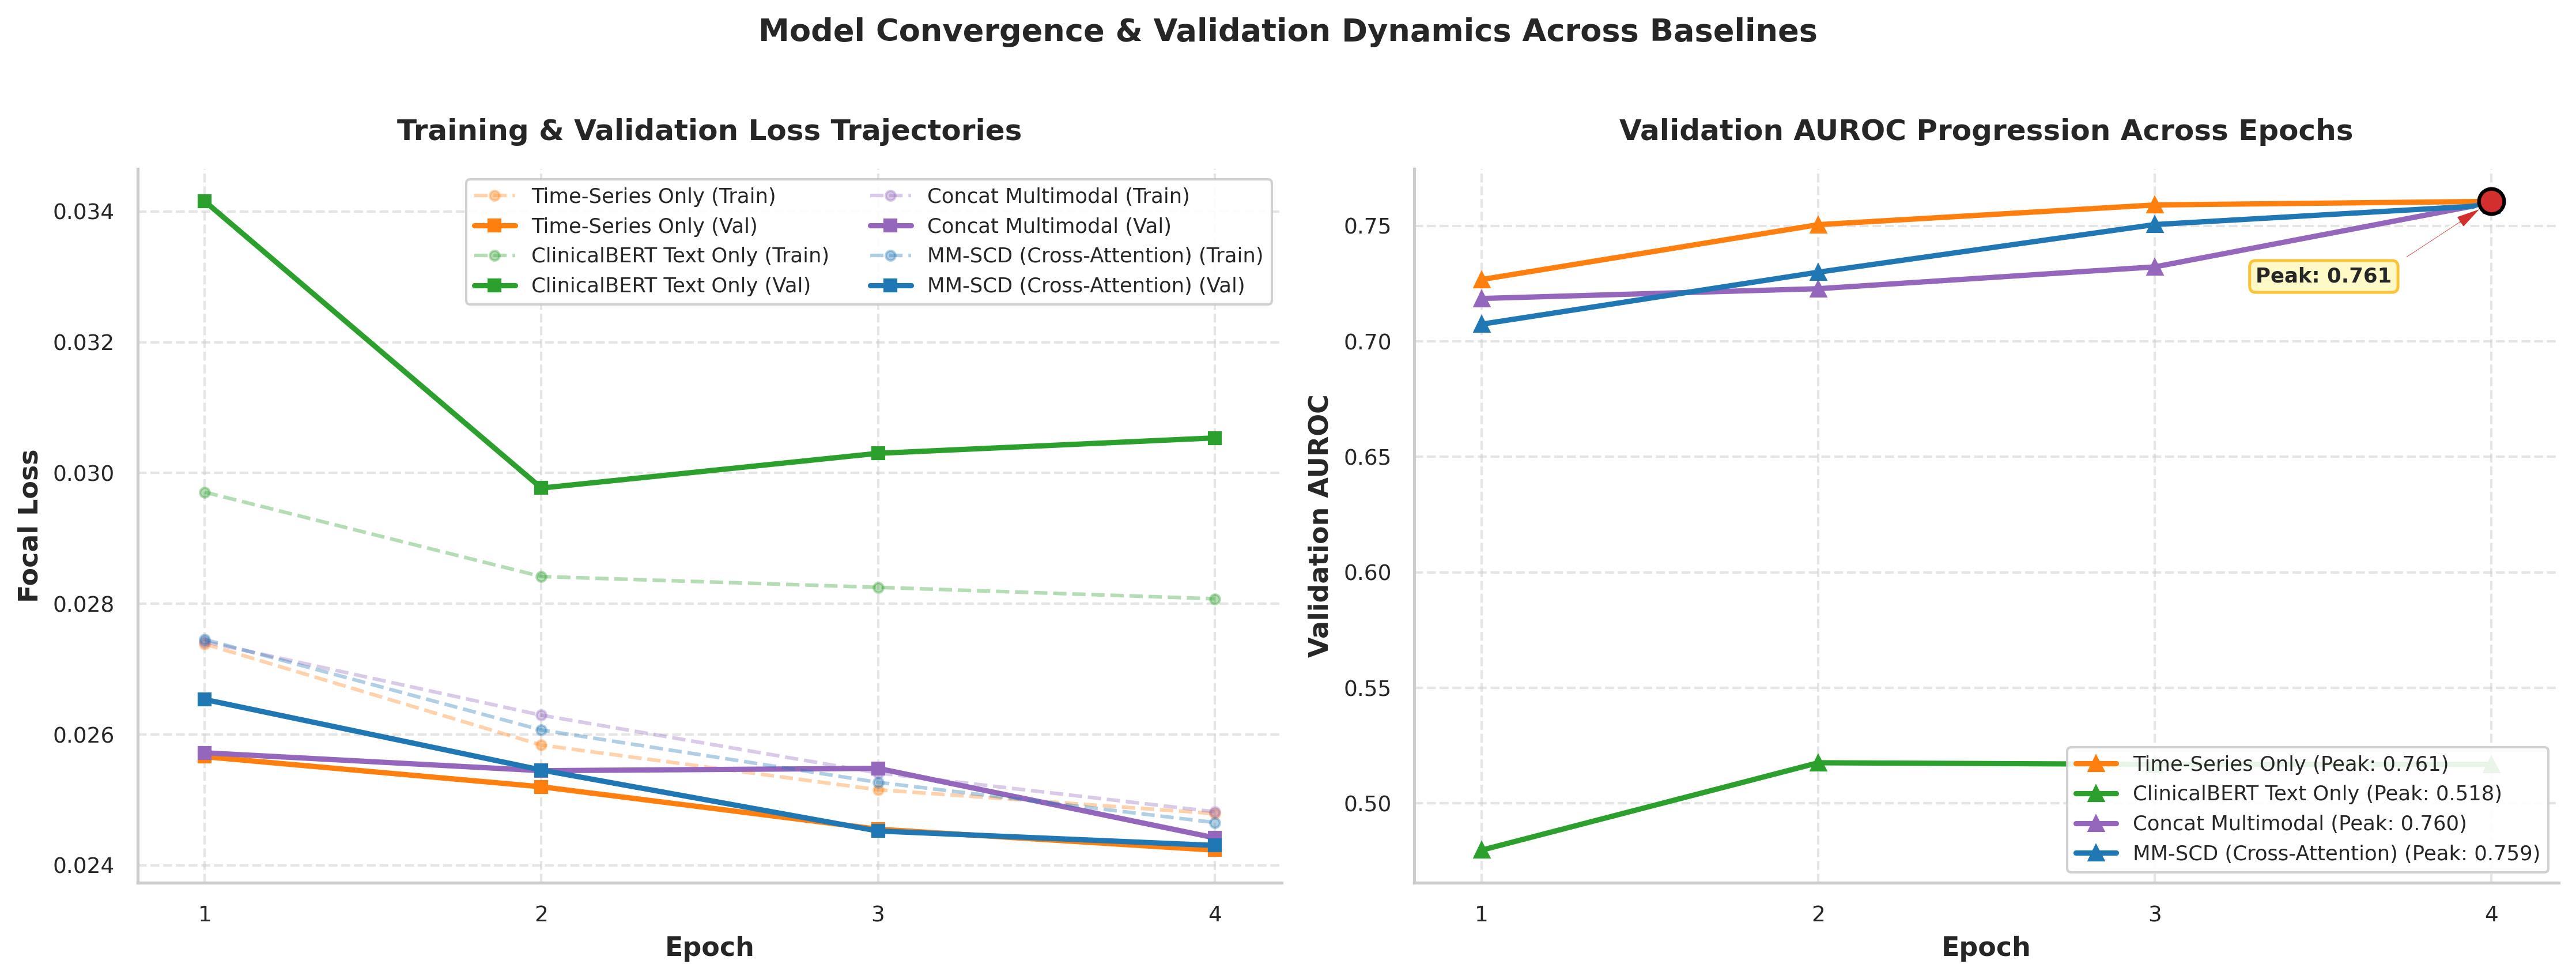

Training curves plot generated and saved to docs/figures/training_validation_curves.png!


In [16]:
# ==============================================================================
# VISUAL STYLING SETUP & CONVERGENCE TRAJECTORY CURVES
# ==============================================================================


# Create figures directory
os.makedirs("docs/figures", exist_ok=True)

# Global model mode mappings & color palettes
plot_modes = ["tabular_mlp"] + modes
all_colors = {
    "tabular_mlp": "#7f7f7f",  # Grey
    "multimodal": "#1f77b4",   # Blue
    "concat": "#9467bd",       # Purple
    "ts_only": "#ff7f0e",      # Orange
    "text_only": "#2ca02c"      # Green
}
all_labels = {
    "tabular_mlp": "Tabular MLP Baseline",
    "multimodal": "MM-SCD (Cross-Attention)",
    "concat": "Concat Multimodal",
    "ts_only": "Time-Series Only",
    "text_only": "ClinicalBERT Text Only"
}

mm_res = evaluation_results['multimodal']
gamma_80 = np.percentile(mm_res['entropies'], 80)
epochs_range = np.arange(1, num_epochs + 1)

# Publication-grade matplotlib styling
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300)

# Subplot 1: Training vs Validation Loss Curves
for mode in modes:
    hist = training_histories[mode]

    # Train loss (faded dashed line for background context)
    axes[0].plot(
        epochs_range, hist['train_loss'],
        linestyle='--', marker='o', markersize=4,
        color=all_colors[mode], alpha=0.35,
        label=f"{all_labels[mode]} (Train)"
    )
    # Val loss (bold solid line for primary emphasis)
    axes[0].plot(
        epochs_range, hist['val_loss'],
        linestyle='-', marker='s', markersize=5,
        color=all_colors[mode], linewidth=2.2,
        label=f"{all_labels[mode]} (Val)"
    )

axes[0].set_title("Training & Validation Loss Trajectories", fontweight='bold', pad=12)
axes[0].set_xlabel("Epoch", fontweight='bold')
axes[0].set_ylabel("Focal Loss", fontweight='bold')
axes[0].set_xticks(epochs_range)
axes[0].set_xlim(0.8, num_epochs + 0.2)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', ncol=2, frameon=True, facecolor='white', framealpha=0.9, edgecolor='#ccc')
sns.despine(ax=axes[0])

# Subplot 2: Validation AUROC Progression
overall_best_auroc = -1.0
overall_best_mode, overall_best_epoch = None, None

for mode in modes:
    hist = training_histories[mode]
    val_aurocs = hist['val_auroc']
    max_idx = int(np.argmax(val_aurocs))
    peak_val = val_aurocs[max_idx]

    if peak_val > overall_best_auroc:
        overall_best_auroc = peak_val
        overall_best_mode = mode
        overall_best_epoch = max_idx + 1

    axes[1].plot(
        epochs_range, val_aurocs,
        marker='^', markersize=6, linewidth=2.2,
        color=all_colors[mode],
        label=f"{all_labels[mode]} (Peak: {peak_val:.3f})"
    )

# Dynamic Callout for Peak AUROC
if overall_best_mode is not None:
    axes[1].scatter(
        [overall_best_epoch], [overall_best_auroc],
        color='#d32f2f', s=110, zorder=5, edgecolor='black', linewidth=1.5
    )
    axes[1].annotate(
        f"Peak: {overall_best_auroc:.3f}",
        xy=(overall_best_epoch, overall_best_auroc),
        xytext=(overall_best_epoch - 0.7, overall_best_auroc - 0.035),
        arrowprops=dict(facecolor='#d32f2f', shrink=0.08, width=1.2, headwidth=6),
        fontweight='bold', fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="#fff9c4", ec="#fbc02d", lw=1.2, alpha=0.95)
    )

axes[1].set_title("Validation AUROC Progression Across Epochs", fontweight='bold', pad=12)
axes[1].set_xlabel("Epoch", fontweight='bold')
axes[1].set_ylabel("Validation AUROC", fontweight='bold')
axes[1].set_xticks(epochs_range)
axes[1].set_xlim(0.8, num_epochs + 0.2)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='#ccc')
sns.despine(ax=axes[1])

plt.suptitle("Model Convergence & Validation Dynamics Across Baselines", y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("docs/figures/training_validation_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("Training curves plot generated and saved to docs/figures/training_validation_curves.png!")

### Diagnostic Suite & Plotly Dashboard
Generates a 6-panel static diagnostic figure (Risk vs Coverage, Entropy, ROC, PR) and creates an interactive HTML Plotly dashboard.

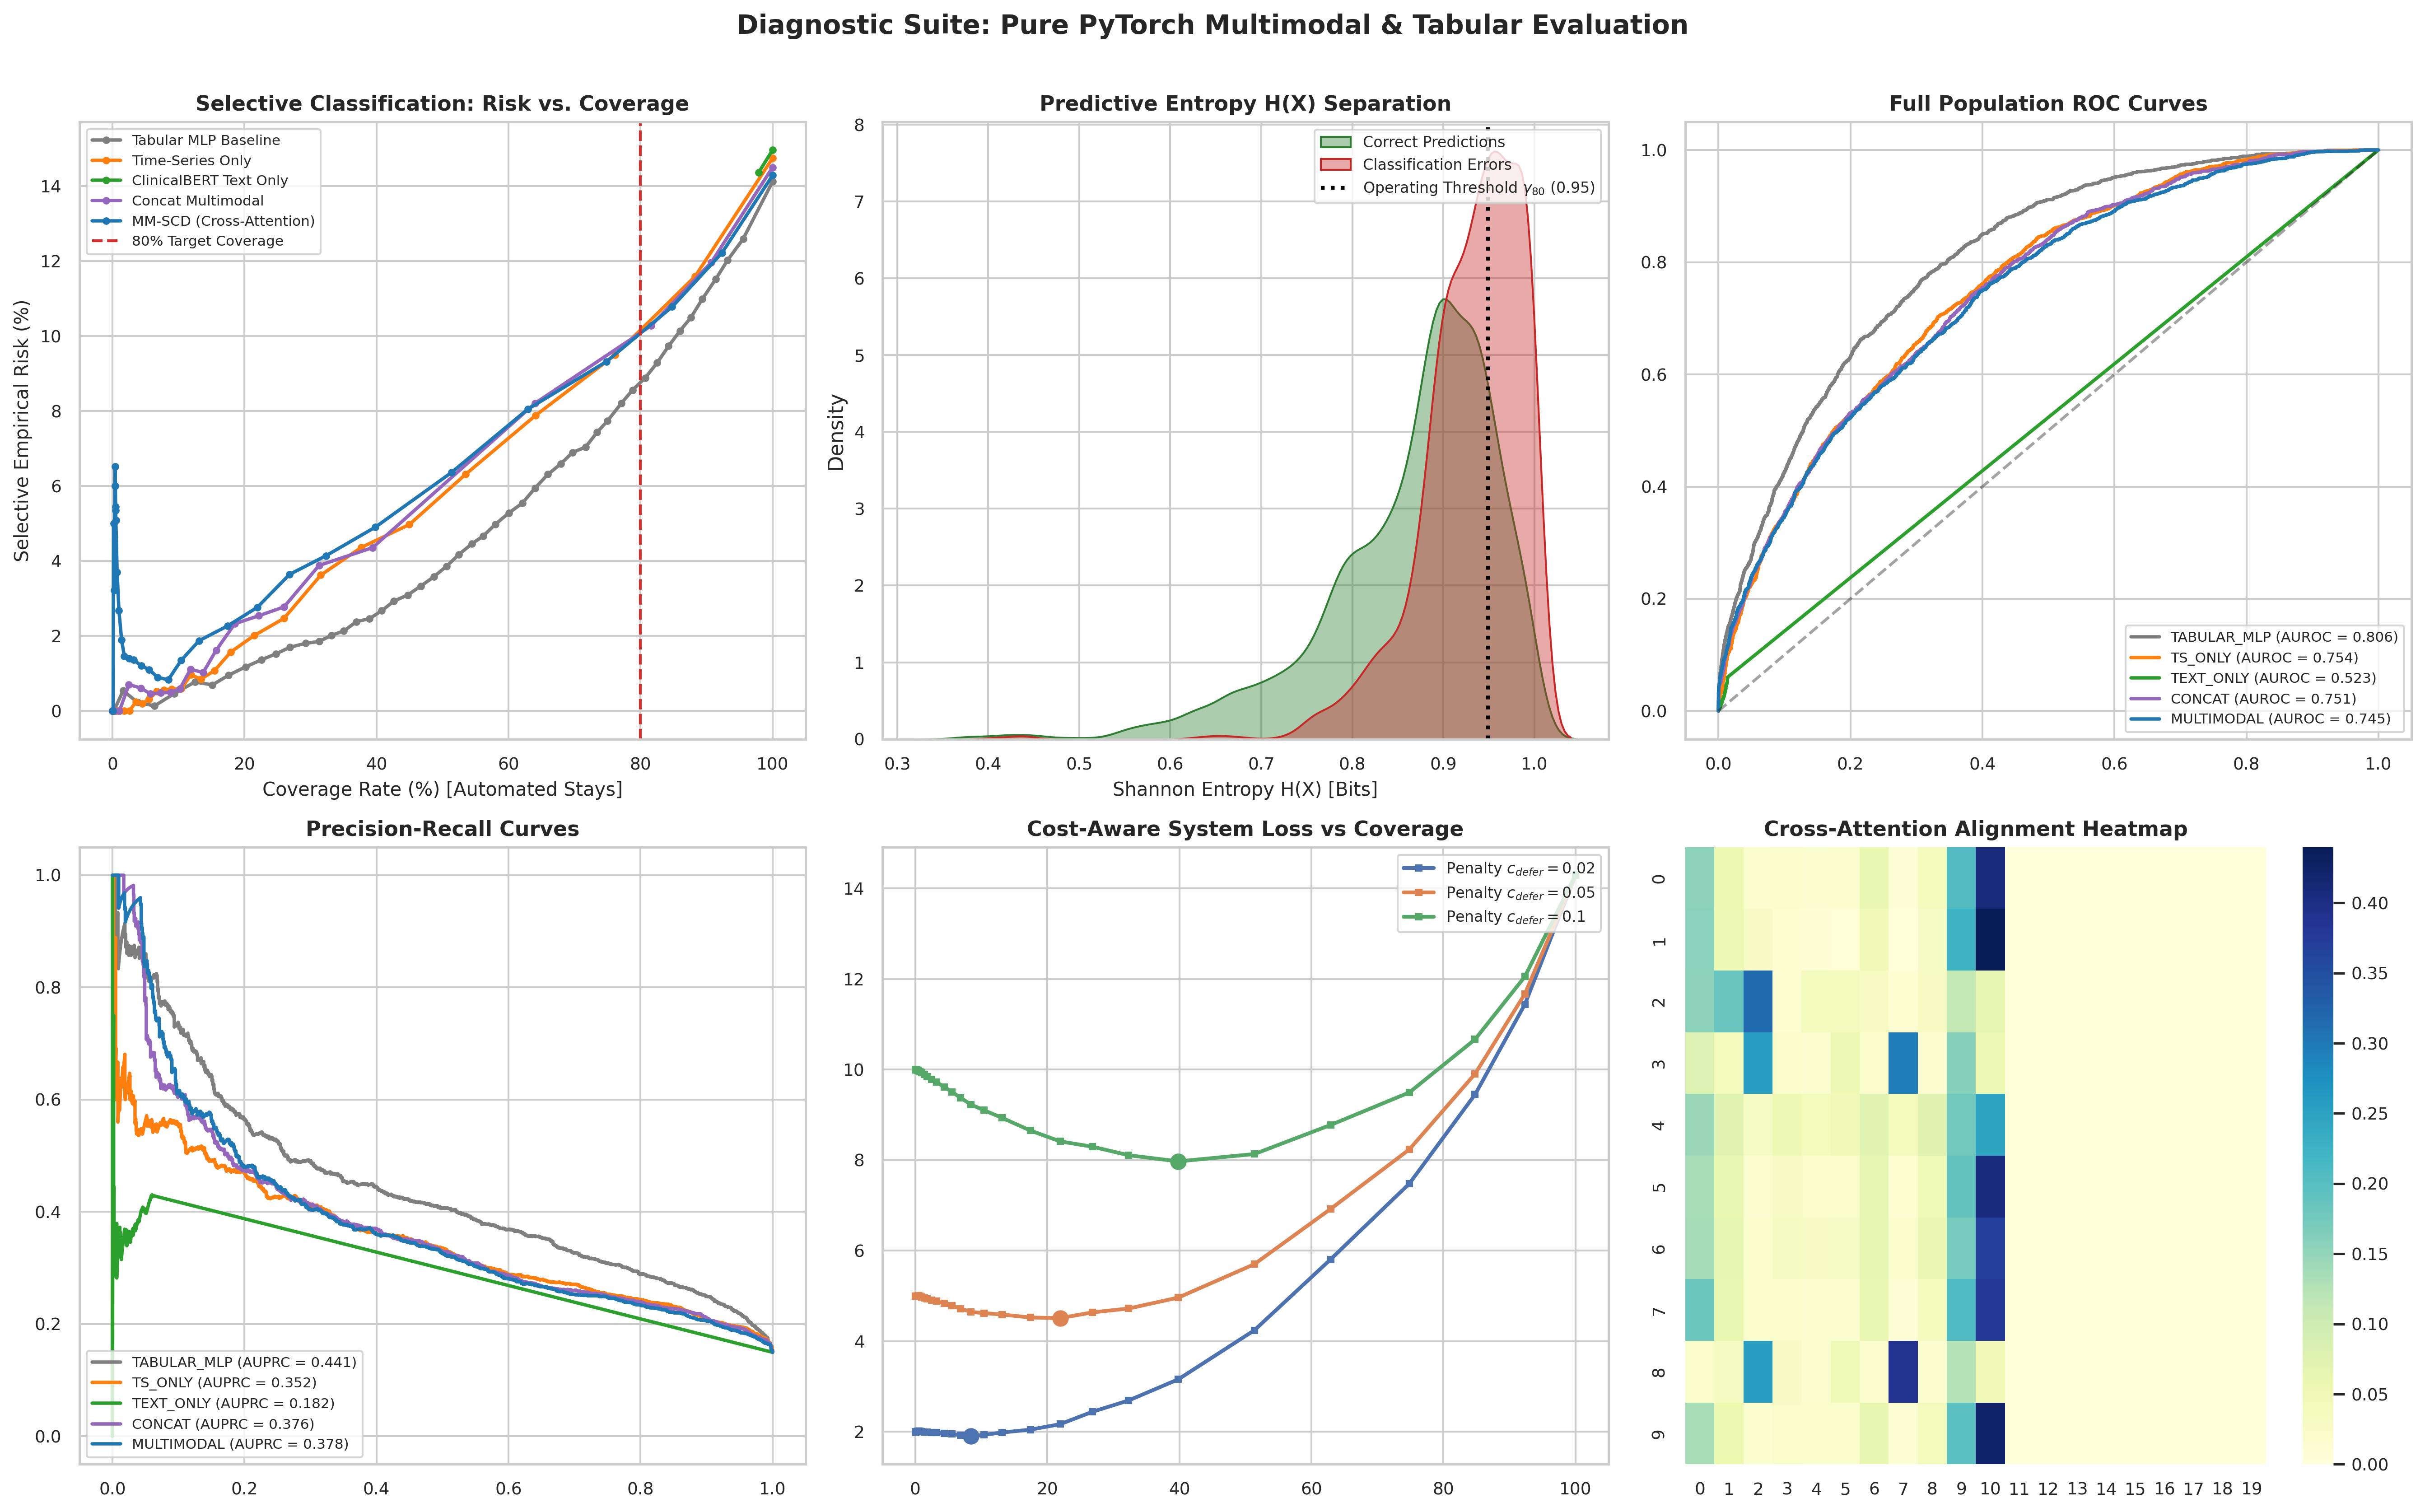

Interactive Plotly Dashboard exported successfully to docs/figures/interactive_diagnostic_dashboard.html!


In [17]:
# ==============================================================================
# STATIC 6-PANEL DIAGNOSTIC SUITE & INTERACTIVE PLOTLY DASHBOARD
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. Comprehensive Diagnostic Suite (6-Panel Static Plot)
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 11), dpi=300)

# Panel 1: Risk vs. Coverage
ax1 = fig.add_subplot(2, 3, 1)
for m in plot_modes:
    res = evaluation_results[m]
    covs, risks = run_risk_coverage_sweep(res['entropies'], res['errors'])
    ax1.plot(covs * 100, risks * 100, marker='o', markersize=3, linewidth=1.8, color=all_colors[m], label=all_labels[m])

ax1.axvline(x=80, color='#d32f2f', linestyle='--', linewidth=1.5, label='80% Target Coverage')
ax1.set_title("Selective Classification: Risk vs. Coverage", fontsize=11, fontweight='bold')
ax1.set_xlabel("Coverage Rate (%) [Automated Stays]", fontsize=10)
ax1.set_ylabel("Selective Empirical Risk (%)", fontsize=10)
ax1.legend(loc='upper left', fontsize=7.5, frameon=True, facecolor='white')

# Panel 2: Entropy Separation
ax2 = fig.add_subplot(2, 3, 2)
correct_mask = (mm_res['errors'] == 0)
error_mask = (mm_res['errors'] == 1)
sns.kdeplot(mm_res['entropies'][correct_mask], ax=ax2, fill=True, color="#2e7d32", label="Correct Predictions", alpha=0.4)
sns.kdeplot(mm_res['entropies'][error_mask], ax=ax2, fill=True, color="#c62828", label="Classification Errors", alpha=0.4)
ax2.axvline(x=gamma_80, color='black', linestyle=':', linewidth=2, label=rf"Operating Threshold $\gamma_{{80}}$ ({gamma_80:.2f})")
ax2.set_title("Predictive Entropy H(X) Separation", fontsize=11, fontweight='bold')
ax2.set_xlabel("Shannon Entropy H(X) [Bits]", fontsize=10)
ax2.legend(loc='upper right', fontsize=8)

# Panel 3: ROC Curves
ax3 = fig.add_subplot(2, 3, 3)
for m in plot_modes:
    res = evaluation_results[m]
    fpr, tpr, _ = TMF.binary_roc(res['pos_probs_tensor'], res['labels_tensor'])
    ax3.plot(fpr.numpy(), tpr.numpy(), linewidth=1.8, color=all_colors[m], label=f"{m.upper()} (AUROC = {res['auroc']:.3f})")
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax3.set_title("Full Population ROC Curves", fontsize=11, fontweight='bold')
ax3.legend(loc='lower right', fontsize=7.5)

# Panel 4: Precision-Recall Curves
ax4 = fig.add_subplot(2, 3, 4)
for m in plot_modes:
    res = evaluation_results[m]
    prec, rec, _ = TMF.binary_precision_recall_curve(res['pos_probs_tensor'], res['labels_tensor'])
    ax4.plot(rec.numpy(), prec.numpy(), linewidth=1.8, color=all_colors[m], label=f"{m.upper()} (AUPRC = {res['auprc']:.3f})")
ax4.set_title("Precision-Recall Curves", fontsize=11, fontweight='bold')
ax4.legend(loc='lower left', fontsize=7.5)

# Panel 5: Cost-Aware System Loss
ax5 = fig.add_subplot(2, 3, 5)
covs, risks = run_risk_coverage_sweep(mm_res['entropies'], mm_res['errors'])
for c_def in [0.02, 0.05, 0.10]:
    sys_loss = compute_cost_aware_system_loss(covs, risks, c_defer=c_def)
    min_idx = np.argmin(sys_loss)
    line, = ax5.plot(covs * 100, sys_loss * 100, marker='s', markersize=3, linewidth=2, label=rf"Penalty $c_{{defer}} = {c_def}$")
    ax5.scatter([covs[min_idx] * 100], [sys_loss[min_idx] * 100], color=line.get_color(), s=60, zorder=5)
ax5.set_title("Cost-Aware System Loss vs Coverage", fontsize=11, fontweight='bold')
ax5.legend(loc='upper right', fontsize=8)

# Panel 6: Cross-Attention Alignment Heatmap
ax6 = fig.add_subplot(2, 3, 6)
if mm_res['attns'] is not None:
    sns.heatmap(mm_res['attns'][:10, 0, :20], ax=ax6, cmap="YlGnBu", cbar=True)
    ax6.set_title("Cross-Attention Alignment Heatmap", fontsize=11, fontweight='bold')
else:
    ax6.text(0.5, 0.5, "Attention Map N/A", ha='center', va='center')

plt.suptitle("Diagnostic Suite: Pure PyTorch Multimodal & Tabular Evaluation", y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("docs/figures/comprehensive_diagnostic_suite.png", dpi=300, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 2. Interactive Plotly Diagnostic Dashboard
# ------------------------------------------------------------------------------
fig_plotly = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Selective Classification: Risk vs Coverage",
        "Predictive Entropy Separation",
        "Full Population ROC Curves",
        "Precision-Recall Curves"
    ),
    horizontal_spacing=0.12,
    vertical_spacing=0.15
)

# Risk vs Coverage
for m in plot_modes:
    res = evaluation_results[m]
    covs, risks = run_risk_coverage_sweep(res['entropies'], res['errors'])
    fig_plotly.add_trace(
        go.Scatter(
            x=covs * 100, y=risks * 100,
            mode='lines+markers', name=all_labels[m],
            line=dict(color=all_colors[m], width=2)
        ),
        row=1, col=1
    )

# Entropy Separation
fig_plotly.add_trace(
    go.Histogram(x=mm_res['entropies'][correct_mask], name='Correct Predictions', marker_color='green', opacity=0.5, histnorm='probability density'),
    row=1, col=2
)
fig_plotly.add_trace(
    go.Histogram(x=mm_res['entropies'][error_mask], name='Errors', marker_color='red', opacity=0.5, histnorm='probability density'),
    row=1, col=2
)

# ROC Curves
for m in plot_modes:
    res = evaluation_results[m]
    fpr, tpr, _ = TMF.binary_roc(res['pos_probs_tensor'], res['labels_tensor'])
    fig_plotly.add_trace(
        go.Scatter(
            x=fpr.numpy(), y=tpr.numpy(),
            mode='lines', name=f"{m.upper()} ROC",
            line=dict(color=all_colors[m], width=2),
            showlegend=False
        ),
        row=2, col=1
    )

# PR Curves
for m in plot_modes:
    res = evaluation_results[m]
    prec, rec, _ = TMF.binary_precision_recall_curve(res['pos_probs_tensor'], res['labels_tensor'])
    fig_plotly.add_trace(
        go.Scatter(
            x=rec.numpy(), y=prec.numpy(),
            mode='lines', name=f"{m.upper()} PR",
            line=dict(color=all_colors[m], width=2),
            showlegend=False
        ),
        row=2, col=2
    )

fig_plotly.update_layout(
    title_text="<b>MM-SCD Interactive Diagnostic Dashboard</b>",
    template="plotly_white",
    height=800, width=1100
)

fig_plotly.update_xaxes(title_text="Coverage Rate (%)", row=1, col=1)
fig_plotly.update_yaxes(title_text="Selective Risk (%)", row=1, col=1)
fig_plotly.update_xaxes(title_text="Shannon Entropy H(X)", row=1, col=2)
fig_plotly.update_yaxes(title_text="Density", row=1, col=2)
fig_plotly.update_xaxes(title_text="False Positive Rate", row=2, col=1)
fig_plotly.update_yaxes(title_text="True Positive Rate", row=2, col=1)
fig_plotly.update_xaxes(title_text="Recall", row=2, col=2)
fig_plotly.update_yaxes(title_text="Precision", row=2, col=2)

plotly_html_path = "docs/figures/interactive_diagnostic_dashboard.html"
fig_plotly.write_html(plotly_html_path)
print(f"Interactive Plotly Dashboard exported successfully to {plotly_html_path}!")

### Clinical Audits: Failure Mode & Reliability
Analyzes the impact of selective deferral on critical false negatives using a confusion matrix and evaluates calibration via a reliability diagram.

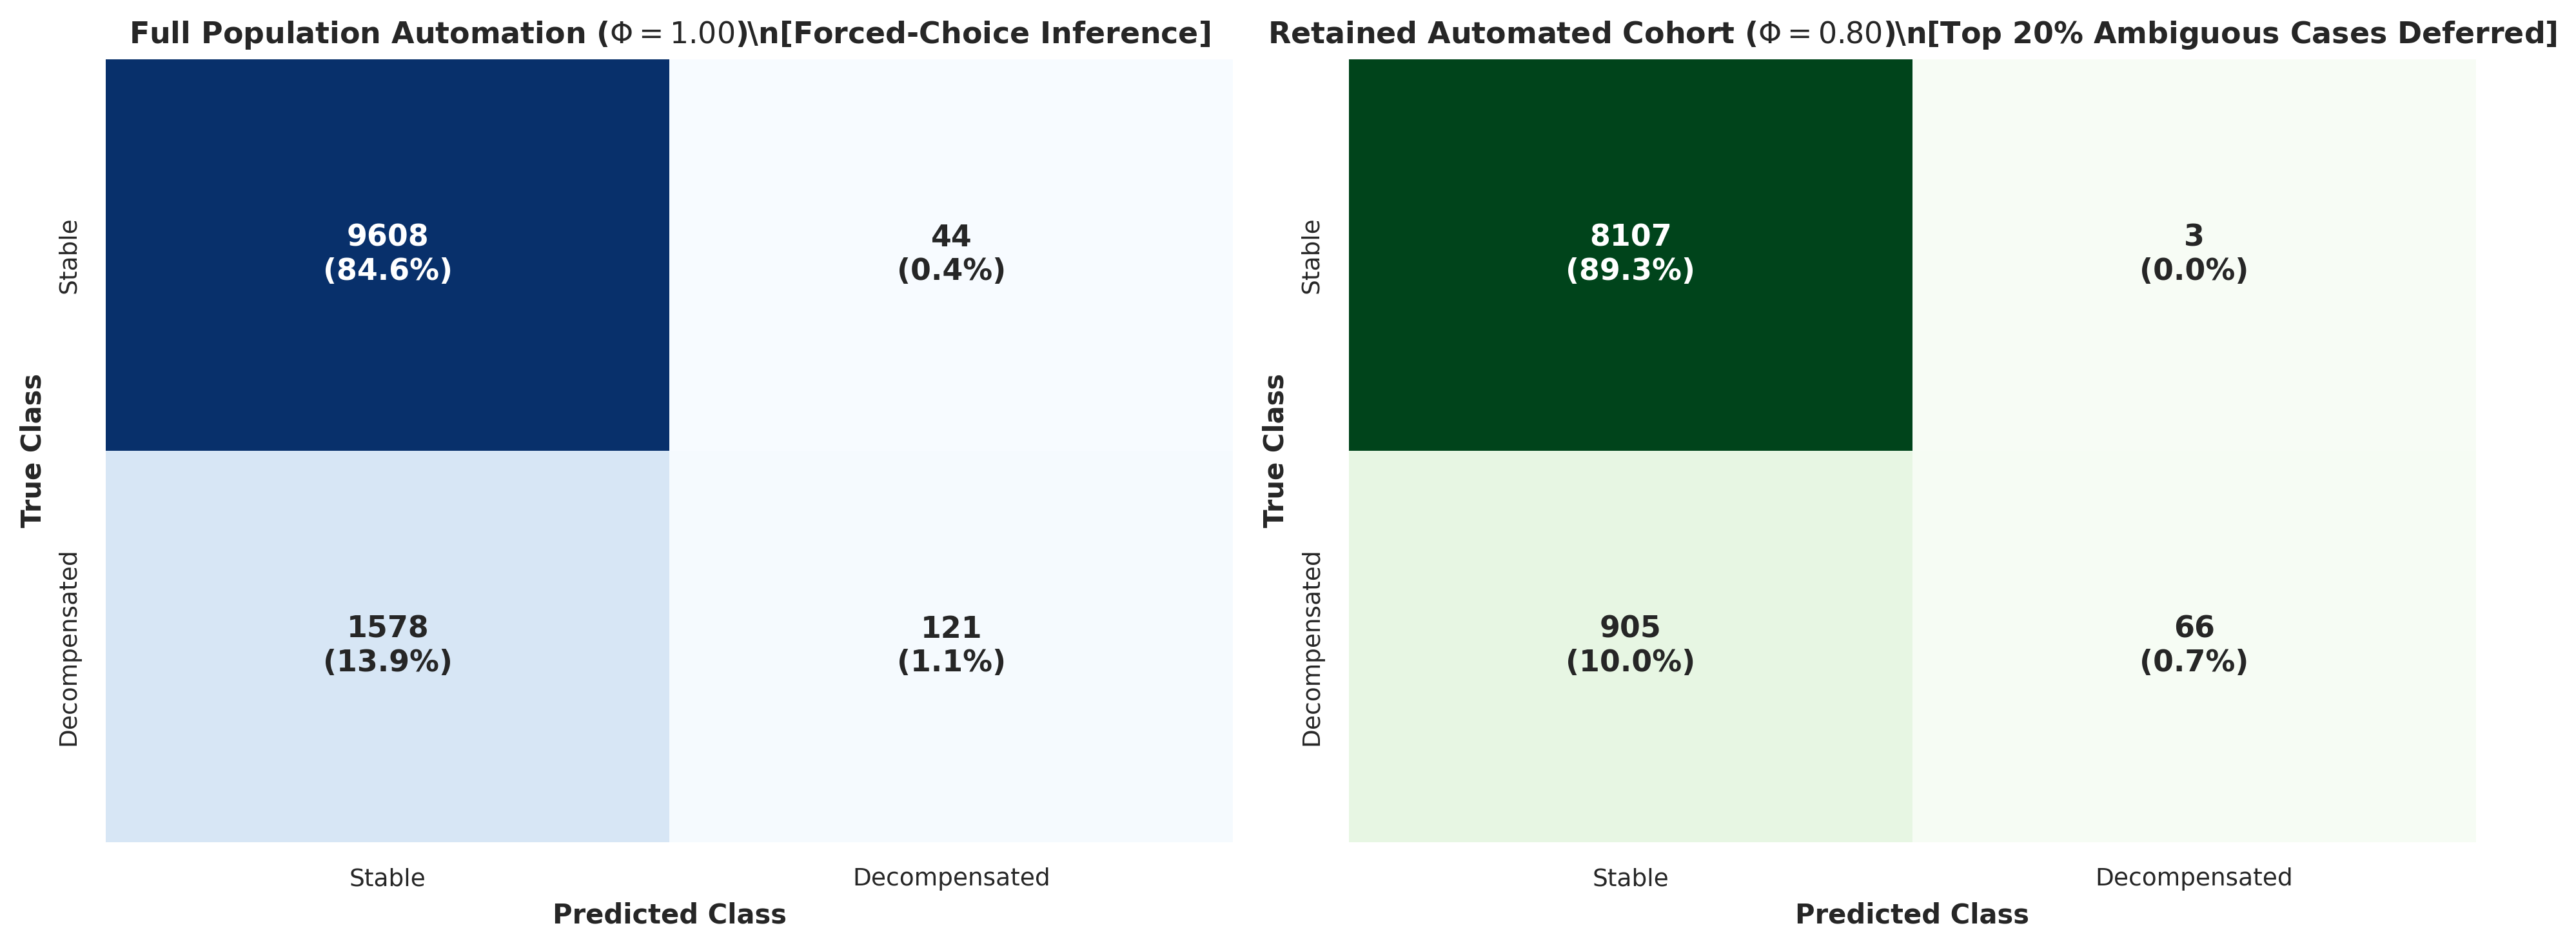


              FAILURE MODE DEFERRAL AUDIT
Full Coverage False Negatives (Missed Decompensations): 1578
Retained Coverage False Negatives (Post-Deferral)    : 905
Critical Clinical Error Reduction                   : 42.65%


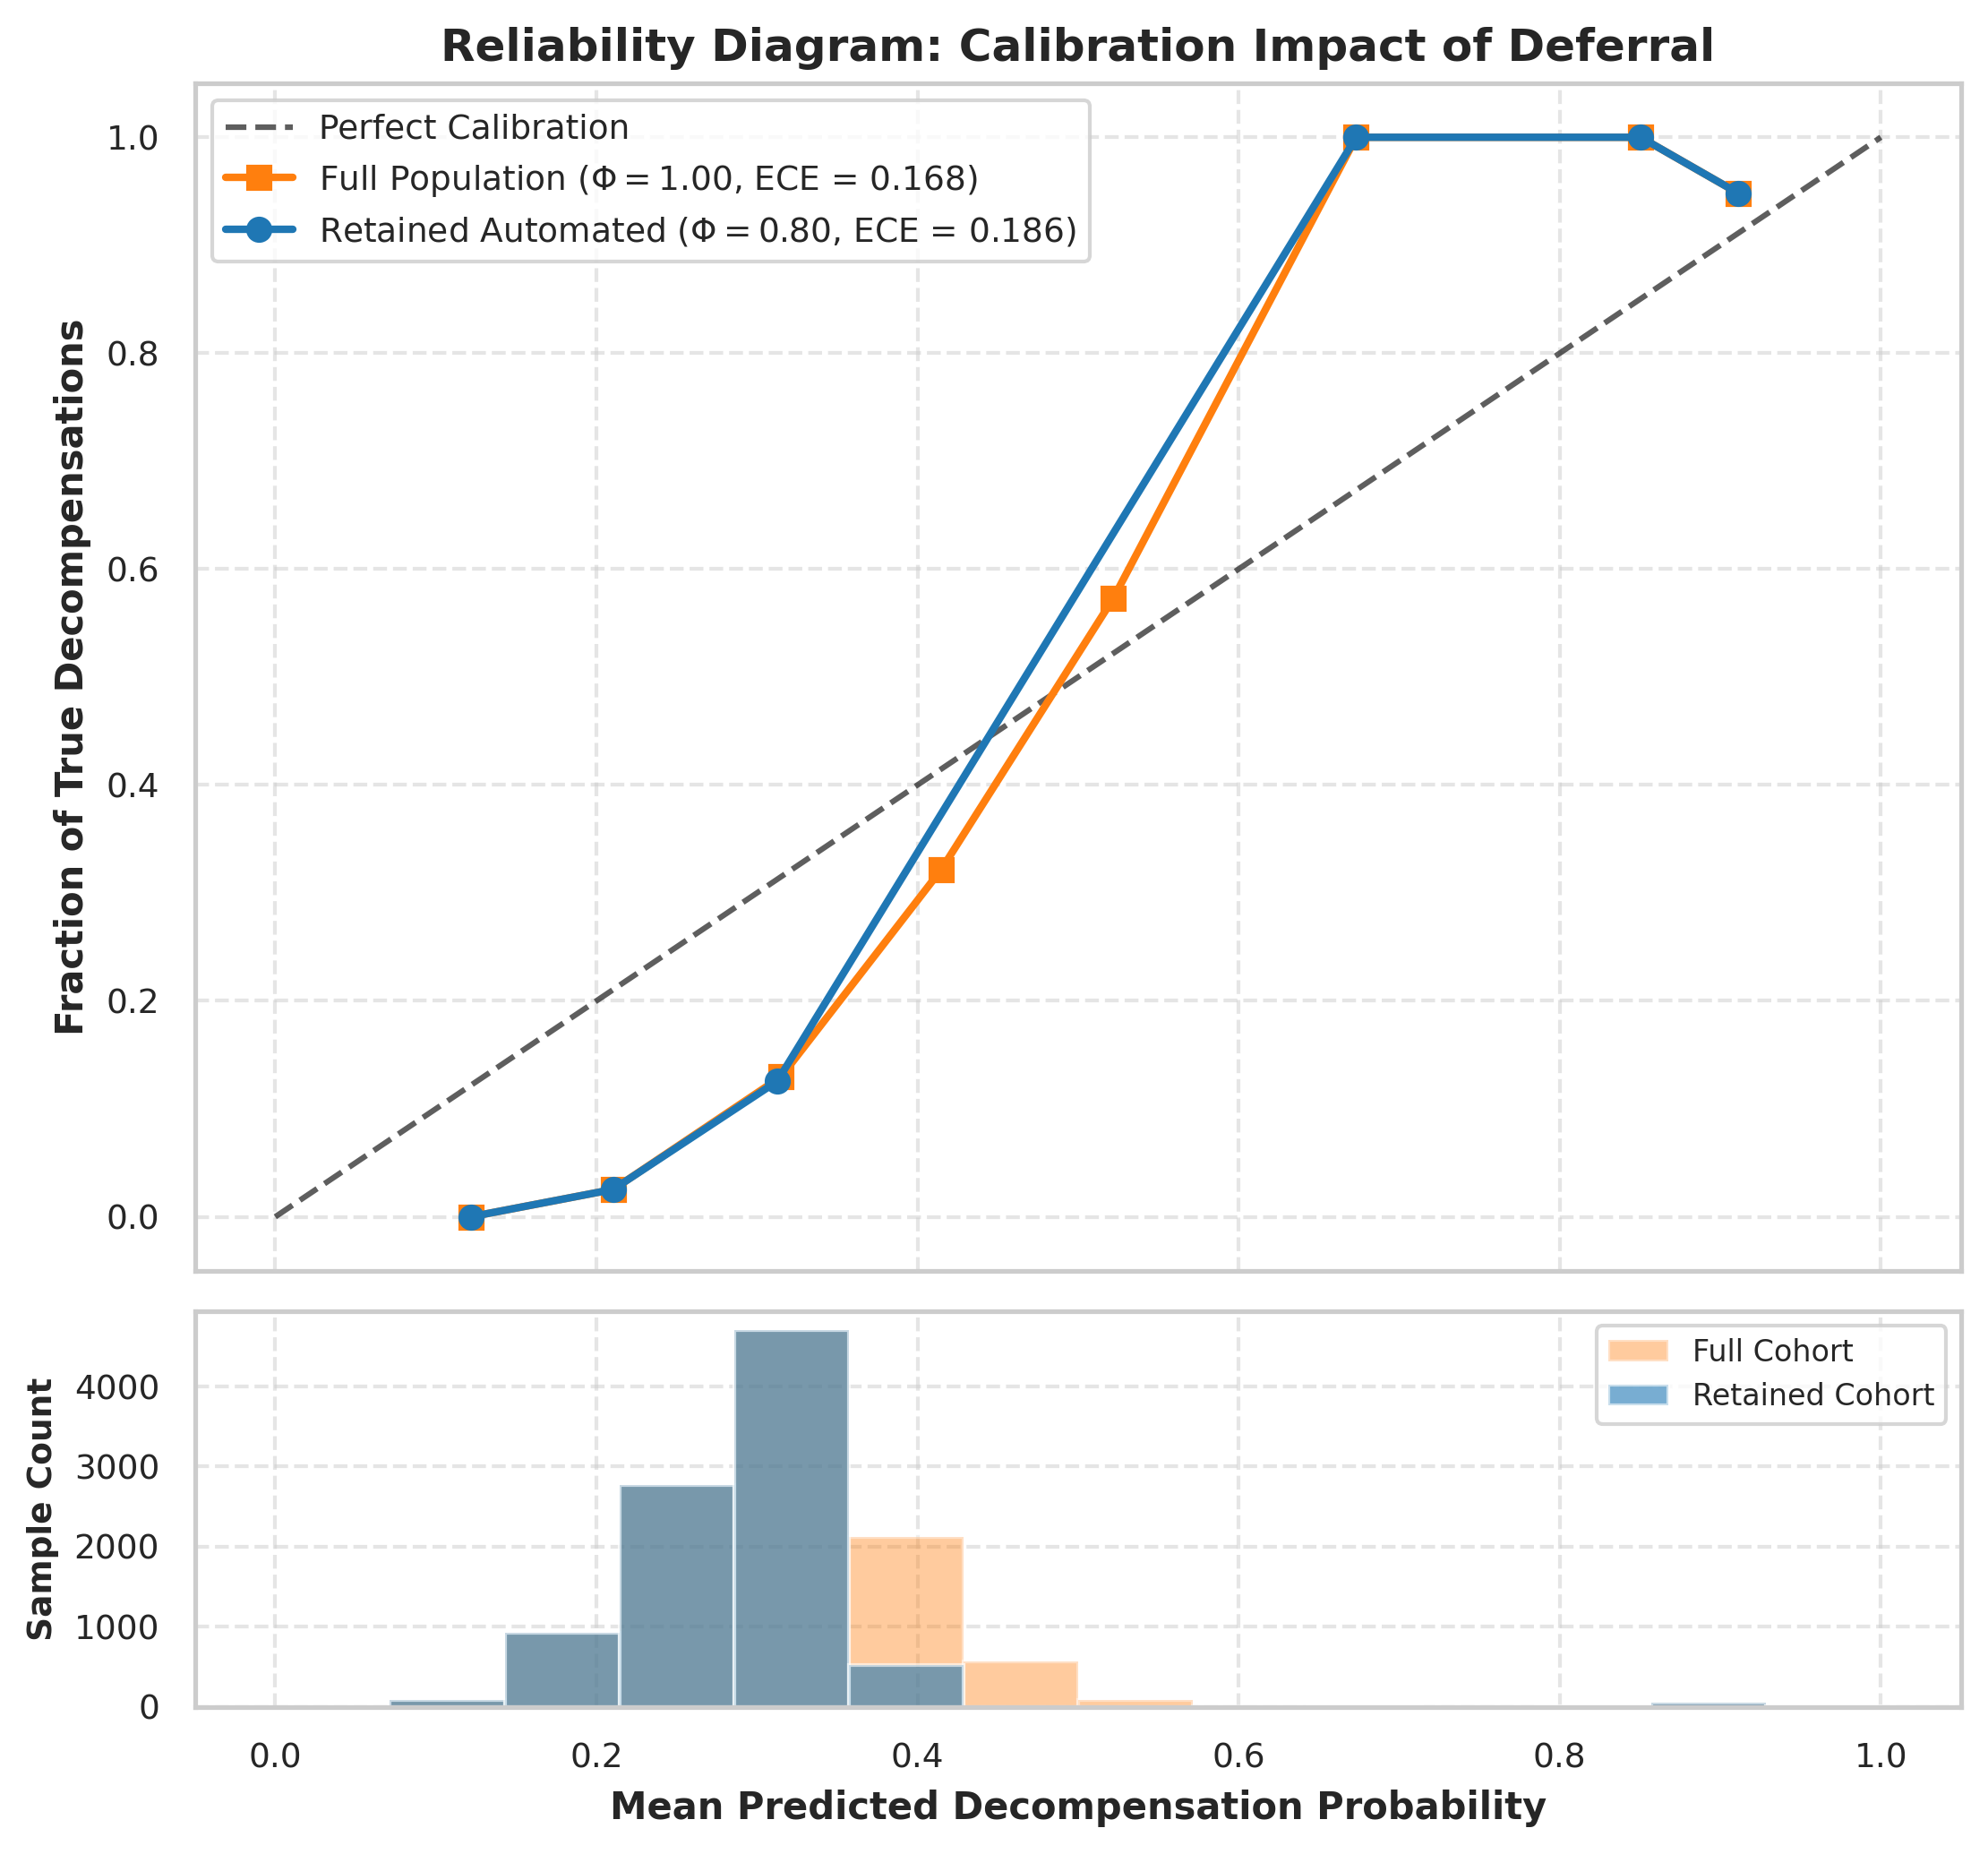

In [18]:
# ==============================================================================
# CLINICAL AUDITS: FAILURE MODE DEFERRAL & RELIABILITY DIAGRAM
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. Failure Mode Deferral Confusion Matrix Audit
# ------------------------------------------------------------------------------
labels_t = mm_res['labels_tensor']
probs_t = mm_res['pos_probs_tensor']
entropies = mm_res['entropies']

preds_t = (probs_t >= 0.5).long()
retained_mask = torch.as_tensor(entropies <= gamma_80, dtype=torch.bool)

labels_retained = labels_t[retained_mask]
preds_retained = preds_t[retained_mask]

cm_full = TMF.binary_confusion_matrix(preds_t, labels_t).cpu().numpy()
cm_retained = TMF.binary_confusion_matrix(preds_retained, labels_retained).cpu().numpy()

def make_annot_matrix(cm):
    total = np.sum(cm)
    annot = np.empty(cm.shape, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cnt = cm[i, j]
            pct = (cnt / total) * 100
            annot[i, j] = f"{cnt}\n({pct:.1f}%)"
    return annot

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

sns.heatmap(
    cm_full, annot=make_annot_matrix(cm_full), fmt='', cmap='Blues', ax=axes[0], cbar=False,
    xticklabels=['Stable', 'Decompensated'], yticklabels=['Stable', 'Decompensated'],
    annot_kws={'size': 11, 'weight': 'bold'}
)
axes[0].set_title(rf"Full Population Automation ($\Phi = 1.00$)\n[Forced-Choice Inference]", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Predicted Class", fontsize=10, fontweight='bold')
axes[0].set_ylabel("True Class", fontsize=10, fontweight='bold')

sns.heatmap(
    cm_retained, annot=make_annot_matrix(cm_retained), fmt='', cmap='Greens', ax=axes[1], cbar=False,
    xticklabels=['Stable', 'Decompensated'], yticklabels=['Stable', 'Decompensated'],
    annot_kws={'size': 11, 'weight': 'bold'}
)
axes[1].set_title(rf"Retained Automated Cohort ($\Phi = 0.80$)\n[Top 20% Ambiguous Cases Deferred]", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Predicted Class", fontsize=10, fontweight='bold')
axes[1].set_ylabel("True Class", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("docs/figures/confusion_matrix_audit.png", dpi=300, bbox_inches='tight')
plt.show()

fn_full = cm_full[1, 0]
fn_retained = cm_retained[1, 0]
fn_reduction = ((fn_full - fn_retained) / fn_full) * 100 if fn_full > 0 else 0

print("\n" + "="*60)
print("              FAILURE MODE DEFERRAL AUDIT")
print("="*60)
print(f"Full Coverage False Negatives (Missed Decompensations): {fn_full}")
print(f"Retained Coverage False Negatives (Post-Deferral)    : {fn_retained}")
print(f"Critical Clinical Error Reduction                   : {fn_reduction:.2f}%")
print("="*60)


# ------------------------------------------------------------------------------
# 2. Reliability Diagram with Sample Density Histogram
# ------------------------------------------------------------------------------
pos_probs = mm_res['pos_probs_tensor']
labels = mm_res['labels_tensor']

prob_true_full, prob_pred_full = compute_calibration_curve_pytorch(labels, pos_probs, n_bins=8)

pos_probs_ret = pos_probs[retained_mask]
labels_ret = labels[retained_mask]

prob_true_ret, prob_pred_ret = compute_calibration_curve_pytorch(labels_ret, pos_probs_ret, n_bins=8)

ece_full = calculate_clinical_calibration(labels, pos_probs)['ece']
ece_retained = calculate_clinical_calibration(labels_ret, pos_probs_ret)['ece']

fig, (ax_cal, ax_hist) = plt.subplots(
    2, 1, figsize=(7.5, 7), dpi=300, sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

ax_cal.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", alpha=0.7)
ax_cal.plot(
    prob_pred_full, prob_true_full, "s-", color="#ff7f0e", linewidth=2, markersize=6,
    label=rf"Full Population ($\Phi = 1.00$, ECE = {ece_full:.3f})"
)
ax_cal.plot(
    prob_pred_ret, prob_true_ret, "o-", color="#1f77b4", linewidth=2, markersize=6,
    label=rf"Retained Automated ($\Phi = 0.80$, ECE = {ece_retained:.3f})"
)

ax_cal.set_title("Reliability Diagram: Calibration Impact of Deferral", fontsize=12, fontweight='bold')
ax_cal.set_ylabel("Fraction of True Decompensations", fontsize=10, fontweight='bold')
ax_cal.legend(loc="upper left", fontsize=9, frameon=True, facecolor='white')
ax_cal.grid(True, linestyle='--', alpha=0.5)

bins = np.linspace(0, 1, 15)
ax_hist.hist(pos_probs.numpy(), bins=bins, color='#ff7f0e', alpha=0.4, label='Full Cohort', edgecolor='white')
ax_hist.hist(pos_probs_ret.numpy(), bins=bins, color='#1f77b4', alpha=0.6, label='Retained Cohort', edgecolor='white')

ax_hist.set_xlabel("Mean Predicted Decompensation Probability", fontsize=10, fontweight='bold')
ax_hist.set_ylabel("Sample Count", fontsize=9, fontweight='bold')
ax_hist.legend(loc="upper right", fontsize=8, frameon=True, facecolor='white')
ax_hist.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("docs/figures/reliability_calibration_diagram.png", dpi=300, bbox_inches='tight')
plt.show()

### Demographic Subgroup Fairness
Audits the model's discriminative performance and clinical deferral rates across different demographic cohorts.

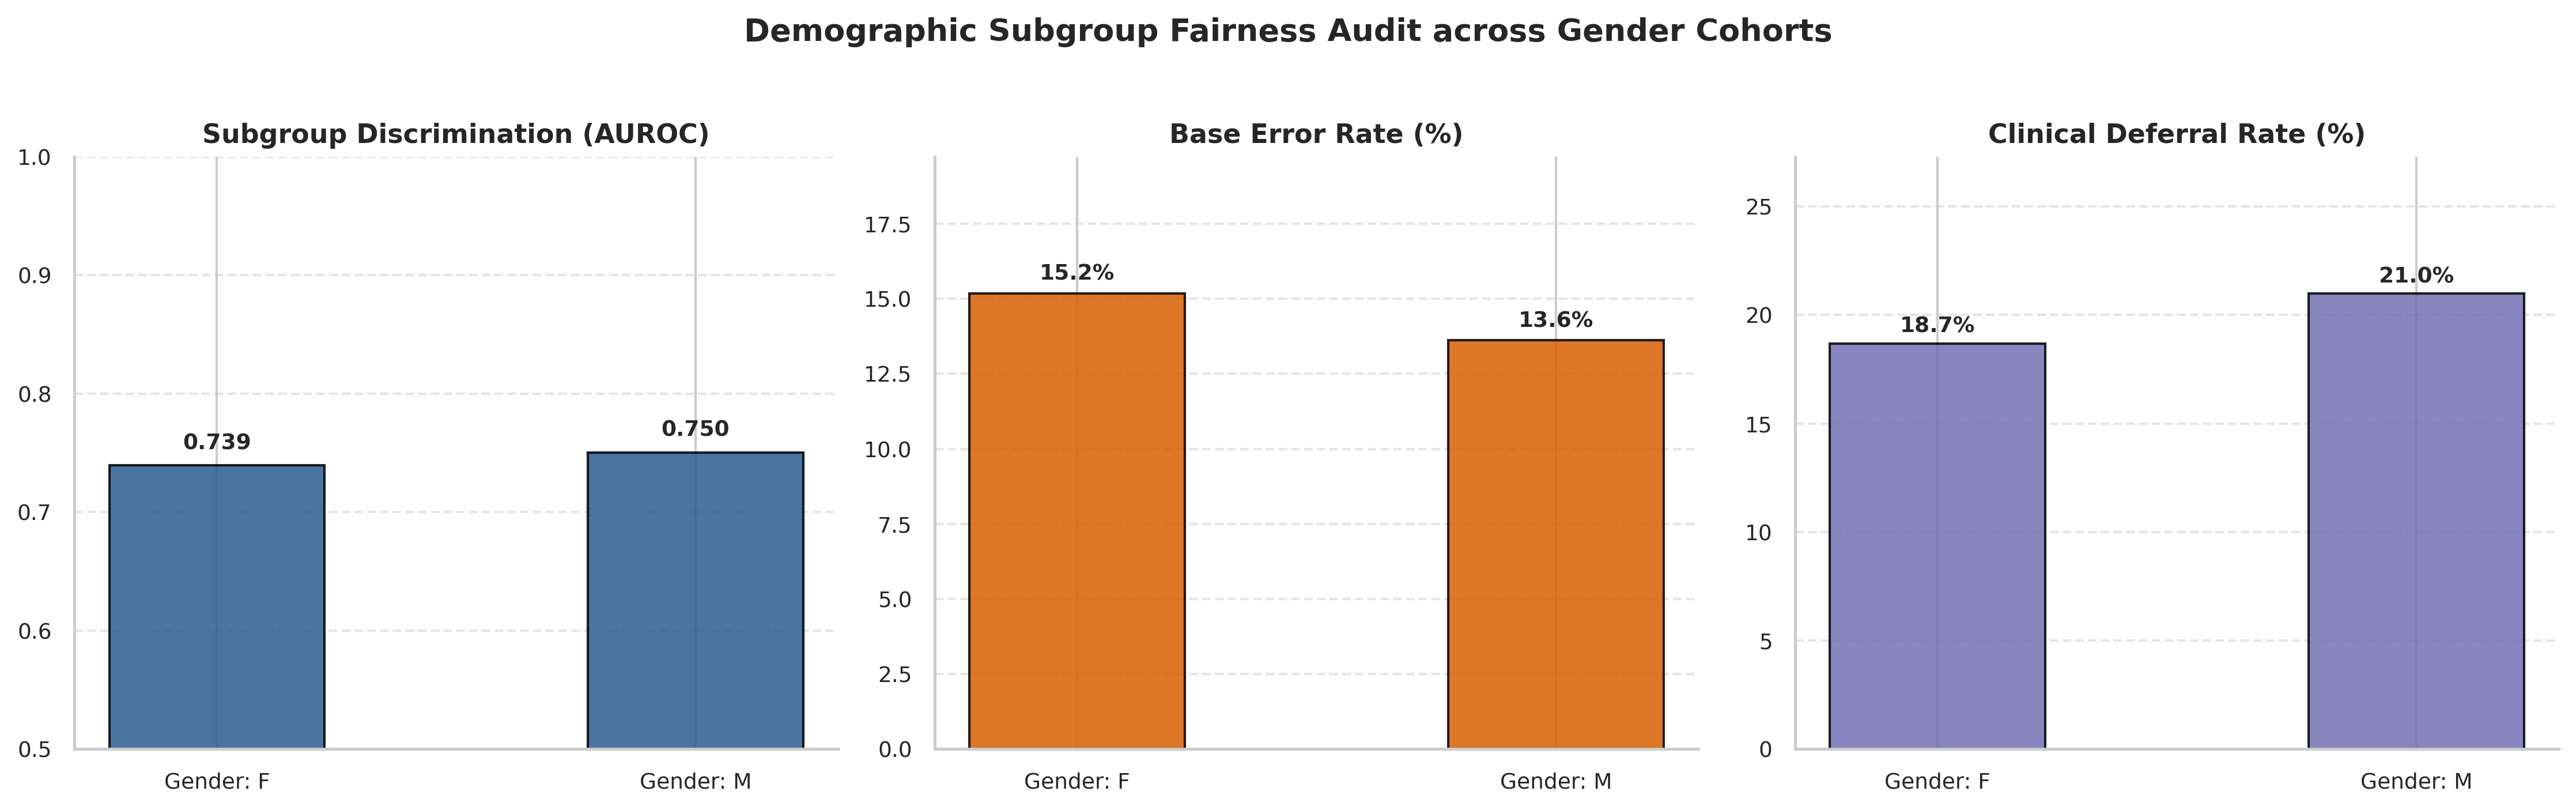


                    DEMOGRAPHIC SUBGROUP AUDIT TABLE
Gender Subgroup  Sample Size (n)    AUROC  Full Error Rate (%)  Deferral Rate (%)
      Gender: F             4896 0.739475            15.175654          18.688725
      Gender: M             6455 0.750357            13.617351          20.991479


In [19]:
# ==============================================================================
# DEMOGRAPHIC SUBGROUP FAIRNESS AUDIT
# ==============================================================================


genders = test_ds.metadata['gender'].values
unique_genders = np.unique(genders)

subgroup_results = []

for g in unique_genders:
    mask = torch.as_tensor(genders == g, dtype=torch.bool)
    sub_labels = mm_res['labels_tensor'][mask]
    sub_probs = mm_res['pos_probs_tensor'][mask]
    sub_entropies = mm_res['entropies'][mask.numpy()]
    sub_errors = mm_res['errors'][mask.numpy()]

    sub_auroc = torch_roc_auc_score(sub_labels, sub_probs)
    sub_defer_rate = np.mean(sub_entropies > gamma_80) * 100
    sub_error_full = np.mean(sub_errors) * 100

    subgroup_results.append({
        'Gender Subgroup': f"Gender: {g}",
        'Sample Size (n)': torch.sum(mask).item(),
        'AUROC': sub_auroc,
        'Full Error Rate (%)': sub_error_full,
        'Deferral Rate (%)': sub_defer_rate
    })

df_subgroup = pd.DataFrame(subgroup_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300, sharey=False)

# Panel 1: AUROC
bars1 = axes[0].bar(df_subgroup['Gender Subgroup'], df_subgroup['AUROC'], color='#2b5c8f', width=0.45, edgecolor='black', alpha=0.85)
axes[0].set_title("Subgroup Discrimination (AUROC)", fontsize=11, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Base Error Rate
bars2 = axes[1].bar(df_subgroup['Gender Subgroup'], df_subgroup['Full Error Rate (%)'], color='#d95f02', width=0.45, edgecolor='black', alpha=0.85)
axes[1].set_title("Base Error Rate (%)", fontsize=11, fontweight='bold')
axes[1].set_ylim(0, max(df_subgroup['Full Error Rate (%)']) * 1.3 if len(df_subgroup) > 0 else 10)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Deferral Rate
bars3 = axes[2].bar(df_subgroup['Gender Subgroup'], df_subgroup['Deferral Rate (%)'], color='#7570b3', width=0.45, edgecolor='black', alpha=0.85)
axes[2].set_title("Clinical Deferral Rate (%)", fontsize=11, fontweight='bold')
axes[2].set_ylim(0, max(df_subgroup['Deferral Rate (%)']) * 1.3 if len(df_subgroup) > 0 else 10)
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars3:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

for ax in axes:
    sns.despine(ax=ax)

plt.suptitle("Demographic Subgroup Fairness Audit across Gender Cohorts", y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("docs/figures/subgroup_fairness_audit.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("                    DEMOGRAPHIC SUBGROUP AUDIT TABLE")
print("="*70)
print(df_subgroup.to_string(index=False))
print("="*70)

### Export Reports & Architecture Diagram
Automatically generates markdown and LaTeX summary tables of the results, and draws the final Multimodal System Architecture diagram.

ACM LaTeX/Markdown Summary Tables exported to:
  - docs/acm_summary_table.md
  - docs/acm_summary_table.tex


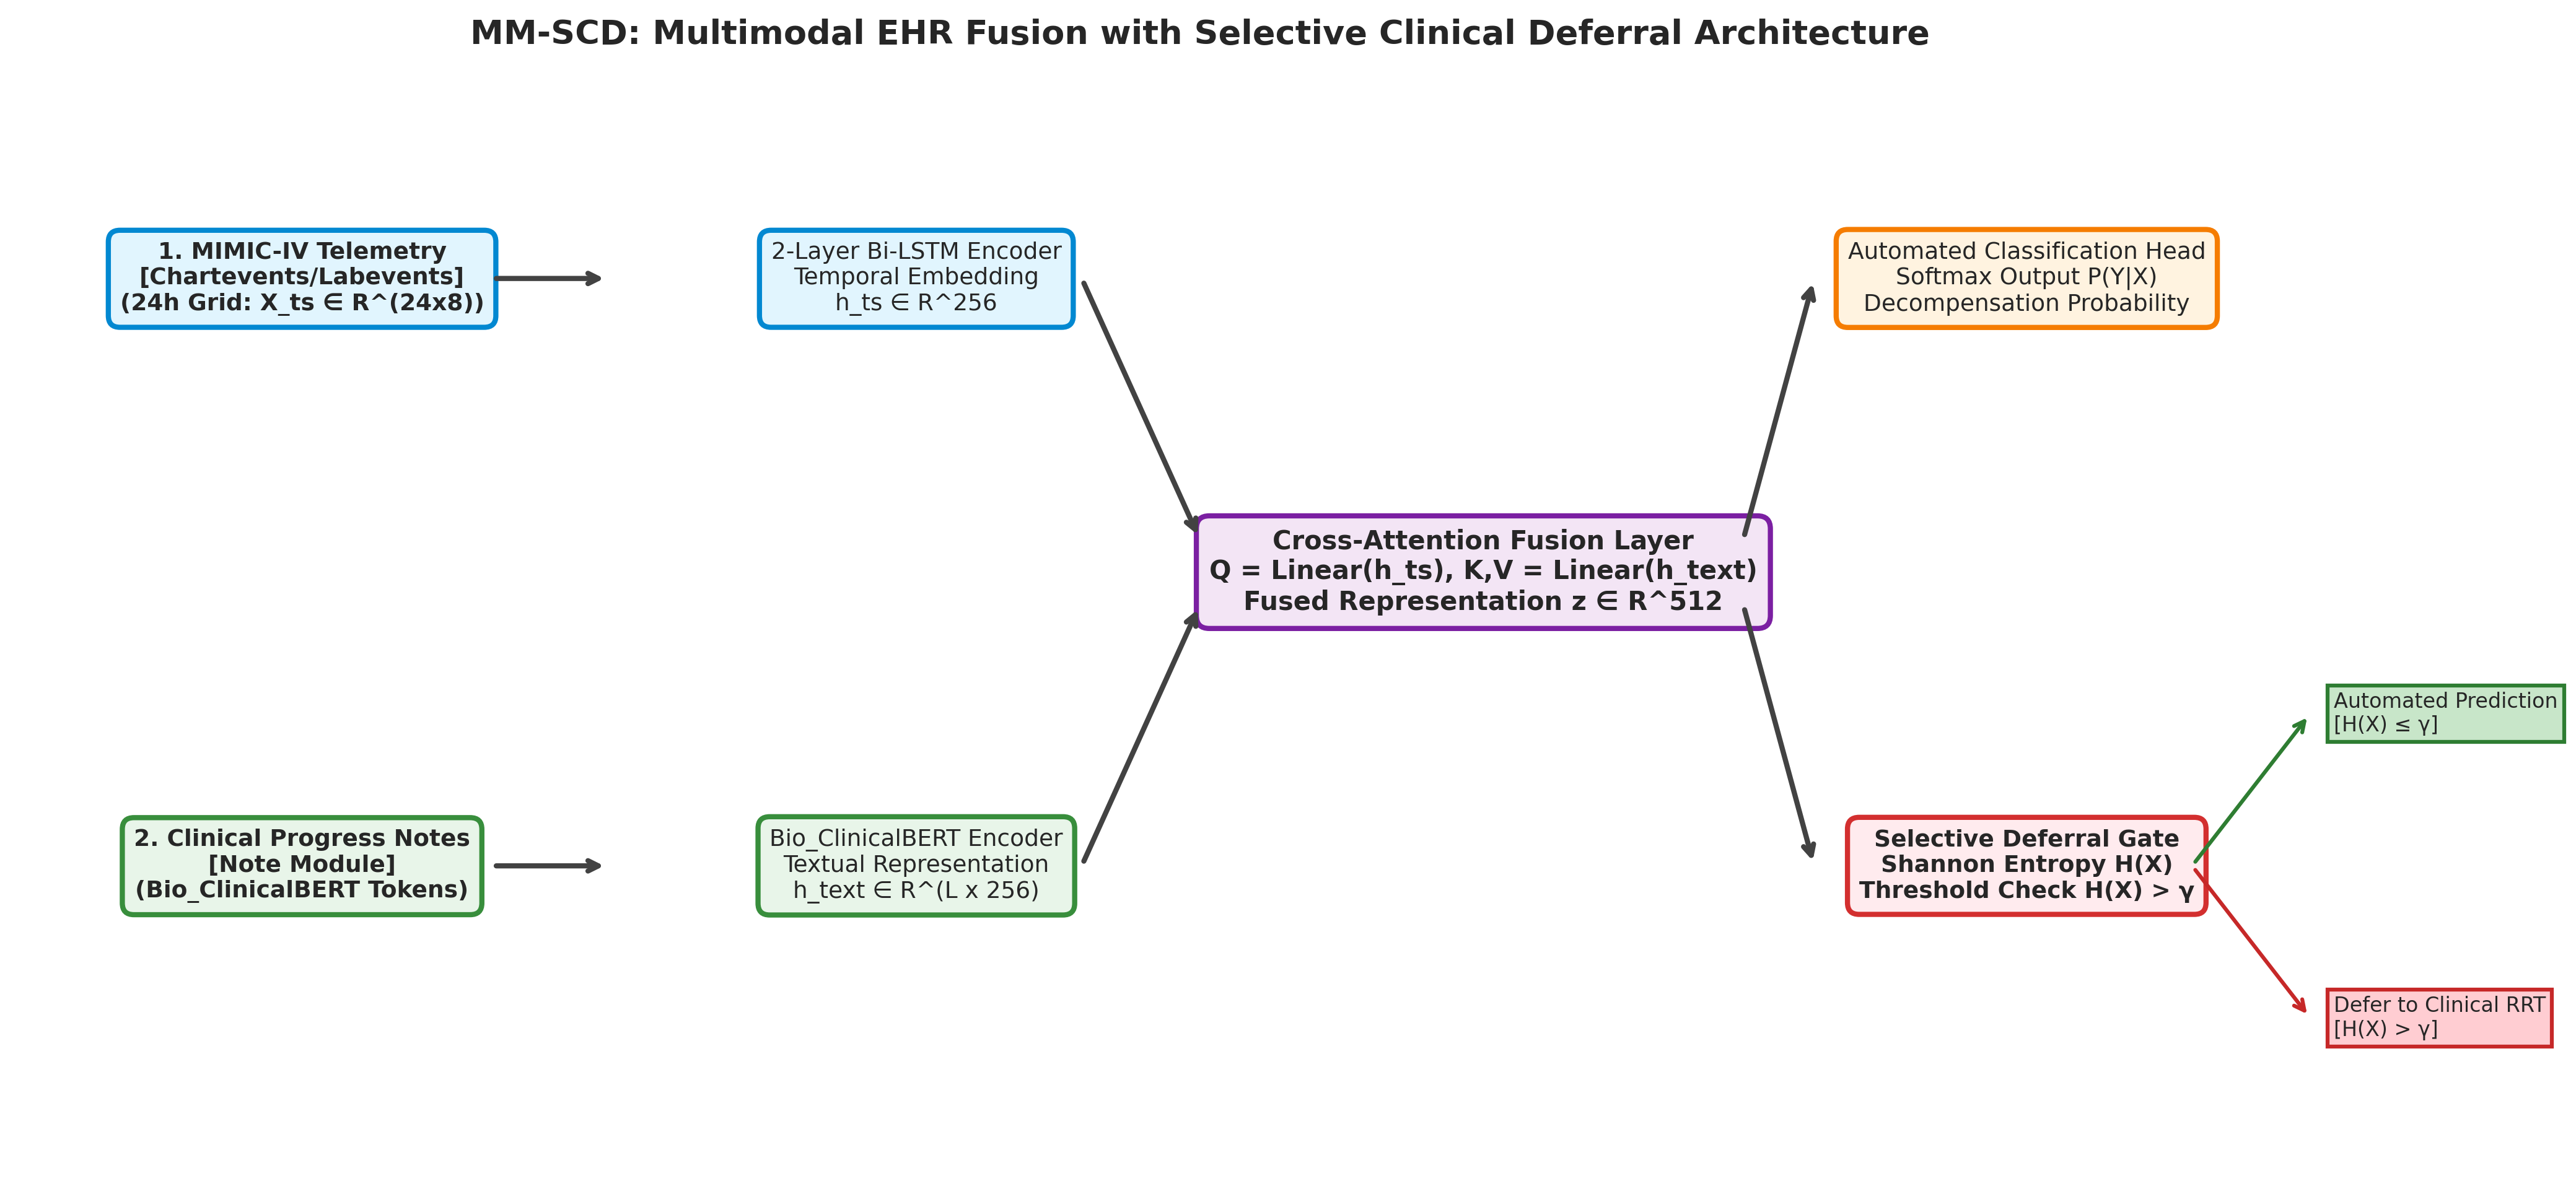

Architecture diagram saved to docs/figures/acm_workflow_architecture.png!


In [20]:
# ==============================================================================
# ACM REPORT TABLE & ARCHITECTURE WORKFLOW DIAGRAM EXPORTER
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. Automated ACM Report Table Exporter
# ------------------------------------------------------------------------------
table_data = []

for m in plot_modes:
    res = evaluation_results[m]
    covs, risks = run_risk_coverage_sweep(res['entropies'], res['errors'])
    idx_80 = np.argmin(np.abs(covs - 0.80)) if len(covs) > 0 else 0

    risk_100 = np.mean(res['errors']) * 100
    risk_80 = risks[idx_80] * 100 if len(risks) > 0 else 0.0
    rel_red = ((risk_100 - risk_80) / risk_100) * 100 if risk_100 > 0 else 0.0

    table_data.append({
        'Model Architecture': all_labels[m],
        'AUROC': f"{res['auroc']:.3f}",
        'AUPRC': f"{res['auprc']:.3f}",
        'ECE': f"{res['ece']:.3f}",
        'Error Rate (Φ=1.00)': f"{risk_100:.2f}%",
        'Error Rate (Φ=0.80)': f"{risk_80:.2f}%",
        'Relative Error Reduction': f"{rel_red:.1f}%"
    })

df_acm_summary = pd.DataFrame(table_data)

md_path = "docs/acm_summary_table.md"
with open(md_path, "w") as f:
    f.write("# Summary of Empirical Results across All Baseline Models\n\n")
    f.write(df_acm_summary.to_markdown(index=False))

tex_path = "docs/acm_summary_table.tex"
latex_str = df_acm_summary.to_latex(
    index=False,
    caption="Comparative empirical performance across all baseline architectures under full coverage (\\Phi=1.00) and selective deferral (\\Phi=0.80).",
    label="tab:baseline_comparison"
)
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"ACM LaTeX/Markdown Summary Tables exported to:\n  - {md_path}\n  - {tex_path}")


# ------------------------------------------------------------------------------
# 2. Workflow System Architecture Diagram
# ------------------------------------------------------------------------------
fig_arch, ax_arch = plt.subplots(figsize=(14, 6.5), dpi=300)
ax_arch.axis('off')

box_blue = dict(boxstyle="round,pad=0.5", fc="#e1f5fe", ec="#0288d1", lw=2)
box_green = dict(boxstyle="round,pad=0.5", fc="#e8f5e9", ec="#388e3c", lw=2)
box_purple = dict(boxstyle="round,pad=0.5", fc="#f3e5f5", ec="#7b1fa2", lw=2)
box_orange = dict(boxstyle="round,pad=0.5", fc="#fff3e0", ec="#f57c00", lw=2)
box_red = dict(boxstyle="round,pad=0.5", fc="#ffebee", ec="#d32f2f", lw=2)

ax_arch.text(0.12, 0.82, "1. MIMIC-IV Telemetry\n[Chartevents/Labevents]\n(24h Grid: X_ts ∈ R^(24x8))", ha="center", va="center", bbox=box_blue, fontsize=9, fontweight="bold")
ax_arch.text(0.12, 0.28, "2. Clinical Progress Notes\n[Note Module]\n(Bio_ClinicalBERT Tokens)", ha="center", va="center", bbox=box_green, fontsize=9, fontweight="bold")

ax_arch.text(0.38, 0.82, "2-Layer Bi-LSTM Encoder\nTemporal Embedding\nh_ts ∈ R^256", ha="center", va="center", bbox=box_blue, fontsize=9)
ax_arch.text(0.38, 0.28, "Bio_ClinicalBERT Encoder\nTextual Representation\nh_text ∈ R^(L x 256)", ha="center", va="center", bbox=box_green, fontsize=9)

ax_arch.text(0.62, 0.55, "Cross-Attention Fusion Layer\nQ = Linear(h_ts), K,V = Linear(h_text)\nFused Representation z ∈ R^512", ha="center", va="center", bbox=box_purple, fontsize=10, fontweight="bold")

ax_arch.text(0.85, 0.82, "Automated Classification Head\nSoftmax Output P(Y|X)\nDecompensation Probability", ha="center", va="center", bbox=box_orange, fontsize=9)
ax_arch.text(0.85, 0.28, "Selective Deferral Gate\nShannon Entropy H(X)\nThreshold Check H(X) > γ", ha="center", va="center", bbox=box_red, fontsize=9, fontweight="bold")

ax_arch.text(0.98, 0.42, "Automated Prediction\n[H(X) ≤ γ]", ha="left", va="center", bbox=dict(boxstyle="square,pad=0.3", fc="#c8e6c9", ec="#2e7d32", lw=1.5), fontsize=8)
ax_arch.text(0.98, 0.14, "Defer to Clinical RRT\n[H(X) > γ]", ha="left", va="center", bbox=dict(boxstyle="square,pad=0.3", fc="#ffcdd2", ec="#c62828", lw=1.5), fontsize=8)

arrow = dict(arrowstyle="->", lw=2, color="#424242")
ax_arch.annotate("", xy=(0.25, 0.82), xytext=(0.20, 0.82), arrowprops=arrow)
ax_arch.annotate("", xy=(0.25, 0.28), xytext=(0.20, 0.28), arrowprops=arrow)
ax_arch.annotate("", xy=(0.50, 0.58), xytext=(0.45, 0.82), arrowprops=arrow)
ax_arch.annotate("", xy=(0.50, 0.52), xytext=(0.45, 0.28), arrowprops=arrow)
ax_arch.annotate("", xy=(0.76, 0.82), xytext=(0.73, 0.58), arrowprops=arrow)
ax_arch.annotate("", xy=(0.76, 0.28), xytext=(0.73, 0.52), arrowprops=arrow)
ax_arch.annotate("", xy=(0.97, 0.42), xytext=(0.92, 0.28), arrowprops=dict(arrowstyle="->", lw=1.5, color="#2e7d32"))
ax_arch.annotate("", xy=(0.97, 0.14), xytext=(0.92, 0.28), arrowprops=dict(arrowstyle="->", lw=1.5, color="#c62828"))

plt.title("MM-SCD: Multimodal EHR Fusion with Selective Clinical Deferral Architecture", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("docs/figures/acm_workflow_architecture.png", dpi=300, bbox_inches='tight')
plt.show()

print("Architecture diagram saved to docs/figures/acm_workflow_architecture.png!")